# File 1 - Feature-only Experiment
## Automated Pedagogical Assessment of Python Code



## 0. Install Dependencies

In [ ]:
!pip install -q datasets xgboost imbalanced-learn

## 1. Imports & Setup

In [ ]:
import ast, os, json, warnings, textwrap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model       import LogisticRegression
from sklearn.ensemble           import RandomForestClassifier
from sklearn.pipeline           import Pipeline
from sklearn.preprocessing      import StandardScaler
from sklearn.model_selection    import train_test_split
from sklearn.metrics            import (classification_report, f1_score,
                                        accuracy_score, confusion_matrix)
from sklearn.utils.class_weight import compute_sample_weight
from imblearn.over_sampling     import SMOTE, RandomOverSampler
from xgboost                    import XGBClassifier

warnings.filterwarnings("ignore")

FIGS  = "/content/figures";  os.makedirs(FIGS,  exist_ok=True)
RSLTS = "/content/results";  os.makedirs(RSLTS, exist_ok=True)

PALETTE = ["#2E4057", "#048A81", "#54C6EB", "#EF946C", "#C4A35A"]
sns.set_theme(style="whitegrid", palette=PALETTE, font_scale=1.05)
plt.rcParams.update({"figure.dpi": 140, "savefig.bbox": "tight",
                     "axes.spines.top": False, "axes.spines.right": False})

print("Imports done.")


Imports done.


## 2. Configuration

In [ ]:
# data
HF_DATASET = "HuggingFaceTB/python-edu-annotations"
SAMPLES    = None   # e.g. 10000 for quick run; None = full dataset
FORCE_RERUN = False

#Google Drive Cache Directory
DRIVE_CACHE = "/content/drive/MyDrive/file1_cache"


## 3. Mount Google Drive

In [ ]:
from google.colab import drive
drive.mount("/content/drive")
os.makedirs(DRIVE_CACHE, exist_ok=True)
print(f"Cache directory: {DRIVE_CACHE}")
print(f"FORCE_RERUN    : {FORCE_RERUN}")


Mounted at /content/drive
Cache directory: /content/drive/MyDrive/file1_cache
FORCE_RERUN    : False


## 4. Cache Helpers

In [ ]:
def cache_path(name):
    """Return full path for a cache file in Drive."""
    return os.path.join(DRIVE_CACHE, name)

def save_npz(name, **arrays):
    path = cache_path(name)
    np.savez_compressed(path, **arrays)
    print(f"  Saved  -> {path}")

def load_npz(name):
    path = cache_path(name)
    data = np.load(path, allow_pickle=True)
    print(f"  Loaded <- {path}")
    return data

def save_json(name, obj):
    path = cache_path(name)
    with open(path, "w") as f:
        json.dump(obj, f, indent=2)
    print(f"  Saved  -> {path}")

def load_json(name):
    path = cache_path(name)
    with open(path) as f:
        obj = json.load(f)
    print(f"  Loaded <- {path}")
    return obj

def is_cached(name):
    """Return True if cache file exists AND FORCE_RERUN is False."""
    return (not FORCE_RERUN) and os.path.exists(cache_path(name))


## 5. Feature Definitions

In [ ]:
doc_features = ["num_comments", "comment_ratio", "has_docstring"]

lexical_features = [
    "num_lines", "avg_line_length",
    "indentation_depth", "has_input_output",
]

syntactic_features = [
    "num_functions", "num_loops", "num_if_statements",
    "total_ast_nodes", "has_main_block",
]

all_features = doc_features + lexical_features + syntactic_features
print(f"Total features: {len(all_features)}")
print(all_features)


Total features: 12
['num_comments', 'comment_ratio', 'has_docstring', 'num_lines', 'avg_line_length', 'indentation_depth', 'has_input_output', 'num_functions', 'num_loops', 'num_if_statements', 'total_ast_nodes', 'has_main_block']


## 6. Load Dataset

In [ ]:
def extract_code_from_prompt(text: str) -> str:
    if "The extract:" not in text:
        return ""
    code = text.split("The extract:")[-1]
    for marker in ("After examining the extract:", "Educational score:"):
        if marker in code:
            code = code.split(marker)[0]
    return code.strip()


In [ ]:
# Dataset itself is not cached (streaming) but the cleaned dataframe is
DF_CACHE = "dataframe.npz"

if is_cached(DF_CACHE):
    print("Loading dataset from Drive cache...")
    cache  = load_npz(DF_CACHE)
    codes  = cache["codes"].tolist()
    scores = cache["scores"].tolist()
    df     = pd.DataFrame({"code": codes, "score": scores})
else:
    from datasets import load_dataset
    print(f"Loading '{HF_DATASET}' from HuggingFace...")
    ds = load_dataset(HF_DATASET, split="train", streaming=True)
    rows = []
    for i, ex in enumerate(ds):
        if SAMPLES and i >= SAMPLES:
            break
        rows.append(ex)
        if (i + 1) % 5000 == 0:
            print(f"  {i+1:,} rows loaded...", flush=True)
    df = pd.DataFrame(rows)
    df["code"]  = df["prompt"].apply(extract_code_from_prompt)
    df          = df.dropna(subset=["score", "code"])
    df["score"] = df["score"].astype(int)
    df          = df[df["score"].between(1, 5) & (df["code"].str.len() >= 20)]
    df          = df.reset_index(drop=True)
    save_npz(DF_CACHE,
             codes=np.array(df["code"].tolist()),
             scores=np.array(df["score"].tolist()))

print(f"\nDataset: {df.shape}")
print(df["score"].value_counts().sort_index().rename("count").to_frame())


Loading dataset from Drive cache...
  Loaded <- /content/drive/MyDrive/file1_cache/dataframe.npz

Dataset: (490921, 2)
        count
score        
1       83121
2      196033
3      161862
4       48724
5        1181


## 7. Train / Val / Test Split (70 / 15 / 15)

In [ ]:
SPLIT_CACHE = "splits.npz"

if is_cached(SPLIT_CACHE):
    print("Loading splits from Drive cache...")
    cache    = load_npz(SPLIT_CACHE)
    tr_idx   = cache["tr_idx"]
    va_idx   = cache["va_idx"]
    te_idx   = cache["te_idx"]
    df_train = df.iloc[tr_idx].reset_index(drop=True)
    df_val   = df.iloc[va_idx].reset_index(drop=True)
    df_test  = df.iloc[te_idx].reset_index(drop=True)
else:
    df_train, df_temp = train_test_split(
        df, test_size=0.30, stratify=df["score"], random_state=42
    )
    df_val, df_test = train_test_split(
        df_temp, test_size=0.50, stratify=df_temp["score"], random_state=42
    )
    save_npz(SPLIT_CACHE,
             tr_idx=np.array(df_train.index),
             va_idx=np.array(df_val.index),
             te_idx=np.array(df_test.index))
    df_train = df_train.reset_index(drop=True)
    df_val   = df_val.reset_index(drop=True)
    df_test  = df_test.reset_index(drop=True)

y_tr = df_train["score"].values
y_va = df_val["score"].values
y_te = df_test["score"].values

print(f"Train : {len(df_train):,}  (70%)")
print(f"Val   : {len(df_val):,}   (15%)")
print(f"Test  : {len(df_test):,}  (15%)")


Loading splits from Drive cache...
  Loaded <- /content/drive/MyDrive/file1_cache/splits.npz
Train : 343,644  (70%)
Val   : 73,638   (15%)
Test  : 73,639  (15%)


## 8. Feature Extraction

In [ ]:
def get_features(code: str, feature_set: str = "all") -> dict:
    features: dict = {}
    try:
        tree = ast.parse(code)
        features["total_ast_nodes"]   = len(list(ast.walk(tree)))
        features["num_functions"]     = sum(isinstance(n, ast.FunctionDef) for n in ast.walk(tree))
        features["num_loops"]         = sum(isinstance(n, (ast.For, ast.While)) for n in ast.walk(tree))
        features["num_if_statements"] = sum(isinstance(n, ast.If) for n in ast.walk(tree))
        features["has_main_block"]    = int("__name__" in code)
        features["has_docstring"]     = int(ast.get_docstring(tree) is not None)
    except SyntaxError:
        features.update({"total_ast_nodes": 0, "num_functions": 0, "num_loops": 0,
                         "num_if_statements": 0, "has_docstring": 0, "has_main_block": 0})
    lines     = code.split("\n")
    num_lines = len(lines)
    denom     = max(1, num_lines)
    features["num_lines"]         = num_lines
    features["num_comments"]      = sum(1 for l in lines if "#" in l)
    features["comment_ratio"]     = features["num_comments"] / denom
    features["avg_line_length"]   = sum(len(l) for l in lines) / denom
    features["indentation_depth"] = (max((len(l) - len(l.lstrip())) for l in lines if l.strip())
                                     if any(l.strip() for l in lines) else 0)
    features["has_input_output"]  = int("input(" in code or "print(" in code)
    if feature_set == "documentation":
        return {k: v for k, v in features.items() if k in doc_features}
    if feature_set == "lexical":
        return {k: v for k, v in features.items() if k in lexical_features}
    if feature_set == "syntactic":
        return {k: v for k, v in features.items() if k in syntactic_features}
    return features

def build_feature_matrix(split_df: pd.DataFrame, feature_set: str = "all") -> pd.DataFrame:
    print(f"  Extracting [{feature_set}] for {len(split_df):,} rows...", flush=True)
    rows = [get_features(c, feature_set) for c in split_df["code"]]
    return pd.DataFrame(rows).fillna(0.0)

def build_feature_matrix_custom(split_df: pd.DataFrame, feature_list: list) -> pd.DataFrame:
    rows = []
    for c in split_df["code"]:
        full = get_features(c, "all")
        rows.append({k: v for k, v in full.items() if k in feature_list})
    return pd.DataFrame(rows).fillna(0.0)


In [ ]:
FEAT_CACHE = "features_all.npz"

if is_cached(FEAT_CACHE):
    print("Loading feature matrices from Drive cache...")
    cache    = load_npz(FEAT_CACHE)
    X_tr_all = cache["X_tr_all"]
    X_te_all = cache["X_te_all"]
else:
    print("Extracting all-feature matrices...")
    X_tr_all = build_feature_matrix(df_train, "all").values
    X_te_all = build_feature_matrix(df_test,  "all").values
    save_npz(FEAT_CACHE, X_tr_all=X_tr_all, X_te_all=X_te_all)

feature_names = all_features
print(f"Train={X_tr_all.shape}  Test={X_te_all.shape}")


Loading feature matrices from Drive cache...
  Loaded <- /content/drive/MyDrive/file1_cache/features_all.npz
Train=(343644, 12)  Test=(73639, 12)


## 9. Model Builders & Helpers

In [ ]:
def build_logreg(class_weight="balanced") -> Pipeline:
    return Pipeline([
        ("scaler", StandardScaler()),
        ("clf",    LogisticRegression(max_iter=3000, class_weight=class_weight, random_state=42)),
    ])

def build_rf(class_weight="balanced") -> RandomForestClassifier:
    return RandomForestClassifier(
        n_estimators=150, class_weight=class_weight, random_state=42, n_jobs=-1
    )

def build_xgb() -> XGBClassifier:
    return XGBClassifier(
        n_estimators=200, max_depth=6, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        objective="multi:softmax", num_class=5,
        eval_metric="mlogloss", tree_method="hist",
        n_jobs=-1, random_state=42, verbosity=0,
    )

MODELS = {
    "LogisticRegression": build_logreg,
    "RandomForest":       build_rf,
    "XGBoost":            build_xgb,
}

def fit_predict(model_name: str, X_tr, y_tr, X_te, class_weight="balanced"):
    if model_name == "XGBoost":
        model = build_xgb()
        sw    = compute_sample_weight("balanced", y=y_tr)
        model.fit(X_tr, y_tr - 1, sample_weight=sw)
        return model.predict(X_te) + 1, model
    model = MODELS[model_name](class_weight=class_weight)
    model.fit(X_tr, y_tr)
    return model.predict(X_te), model

def evaluate(y_true, y_pred) -> dict:
    return {
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "macro_f1": float(f1_score(y_true, y_pred, average="macro", zero_division=0)),
        "report":   classification_report(y_true, y_pred, zero_division=0, output_dict=True),
        "cm":       confusion_matrix(y_true, y_pred).tolist(),
    }


## 10. Plotting Helpers

In [ ]:
def savefig(name: str):
    path = os.path.join(FIGS, name)
    plt.savefig(path)
    plt.show()
    plt.close()
    print(f"  saved -> {path}")

def plot_confusion_matrix(cm_array, title: str, fname: str):
    cm   = np.array(cm_array)
    norm = cm.astype(float) / cm.sum(axis=1, keepdims=True).clip(1)
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    fig.suptitle(title, fontsize=13, fontweight="bold", y=1.01)
    for ax, data, fmt, sub in zip(axes, [cm, norm], ["d", ".2f"], ["Counts", "Row-normalised"]):
        sns.heatmap(data, annot=True, fmt=fmt, ax=ax, cmap="Blues",
                    xticklabels=range(1,6), yticklabels=range(1,6),
                    linewidths=.4, cbar_kws={"shrink": .8})
        ax.set_xlabel("Predicted Score"); ax.set_ylabel("True Score")
        ax.set_title(sub, fontsize=11)
    plt.tight_layout()
    savefig(fname)

def bar_comparison(records: list, metric: str, title: str, fname: str, x_key: str = "label"):
    dfp = pd.DataFrame(records).sort_values(metric, ascending=False)
    fig, ax = plt.subplots(figsize=(max(7, len(dfp)*1.3), 5))
    bars = ax.bar(dfp[x_key], dfp[metric],
                  color=PALETTE[:len(dfp)], edgecolor="white", linewidth=.6, width=.6)
    ax.bar_label(bars, fmt="%.4f", padding=4, fontsize=9)
    ax.set_ylim(0, min(1.0, dfp[metric].max() * 1.2))
    ax.set_ylabel(metric.replace("_"," ").title())
    ax.set_title(title, fontweight="bold")
    ax.tick_params(axis="x", rotation=30)
    plt.tight_layout()
    savefig(fname)

def line_chart(records: list, x: str, y: str, hue: str,
               title: str, fname: str, xlabel: str = ""):
    dfp = pd.DataFrame(records).sort_values(x)
    fig, ax = plt.subplots(figsize=(8, 5))
    for i, (grp_val, grp) in enumerate(dfp.groupby(hue)):
        ax.plot(grp[x], grp[y], marker="o", label=grp_val,
                color=PALETTE[i % len(PALETTE)], linewidth=2, markersize=7)
    ax.set_xlabel(xlabel or x); ax.set_ylabel(y.replace("_"," ").title())
    ax.set_title(title, fontweight="bold"); ax.legend(title=hue)
    plt.tight_layout()
    savefig(fname)

def feature_importance_plot(importances, feature_names, title, fname, top=15):
    idx    = np.argsort(importances)[::-1][:top]
    names  = [feature_names[i] for i in idx]
    vals   = importances[idx]
    fig, ax = plt.subplots(figsize=(9, max(4, top * 0.38)))
    colors  = sns.color_palette("mako", top)[::-1]
    ax.barh(names[::-1], vals[::-1], color=colors, edgecolor="white", linewidth=.4)
    ax.set_xlabel("Importance"); ax.set_title(title, fontweight="bold")
    plt.tight_layout()
    savefig(fname)


## Experiment 1 — EDA

[EDA] Label distribution...


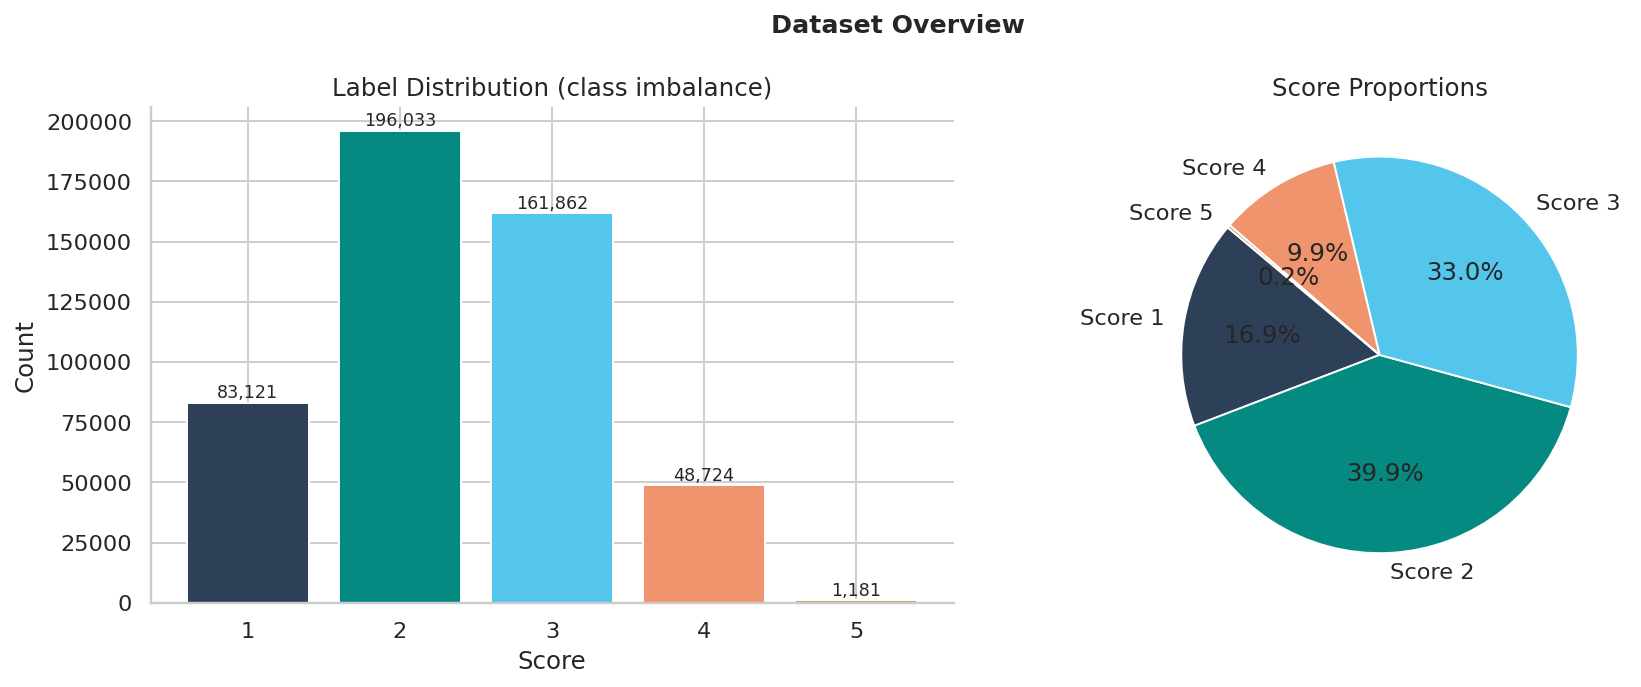

  saved -> /content/figures/eda_label_distribution.png


In [ ]:
print("[EDA] Label distribution...")
vc = df["score"].value_counts().sort_index()
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Dataset Overview", fontweight="bold", fontsize=13)
axes[0].bar(vc.index.astype(str), vc.values, color=PALETTE, edgecolor="white")
axes[0].set_xlabel("Score"); axes[0].set_ylabel("Count")
axes[0].set_title("Label Distribution (class imbalance)")
for i, v in zip(vc.index, vc.values):
    axes[0].text(i-1, v + vc.max()*0.01, f"{v:,}", ha="center", fontsize=9)
axes[1].pie(vc.values, labels=[f"Score {i}" for i in vc.index],
            colors=PALETTE, autopct="%1.1f%%", startangle=140,
            wedgeprops={"edgecolor": "white"})
axes[1].set_title("Score Proportions")
plt.tight_layout()
savefig("eda_label_distribution.png")


In [ ]:
print("[EDA] Feature statistics...")
X_all = build_feature_matrix(df, "all")
stats = X_all.describe().T[["mean","std","min","max"]].round(3)
stats.to_csv(os.path.join(RSLTS, "feature_stats.csv"))
print(stats)


[EDA] Feature statistics...
  Extracting [all] for 490,921 rows...
                      mean      std    min     max
total_ast_nodes    103.495  124.886  0.000  1450.0
num_functions        1.178    2.010  0.000    34.0
num_loops            0.362    0.959  0.000    27.0
num_if_statements    0.695    1.572  0.000    45.0
has_main_block       0.085    0.278  0.000     1.0
has_docstring        0.103    0.304  0.000     1.0
num_lines           44.361   23.045  1.000   557.0
num_comments         4.211    6.560  0.000   269.0
comment_ratio        0.093    0.139  0.000     1.0
avg_line_length     30.290    8.930  1.579   495.0
indentation_depth   12.454   10.267  0.000   328.0
has_input_output     0.219    0.413  0.000     1.0


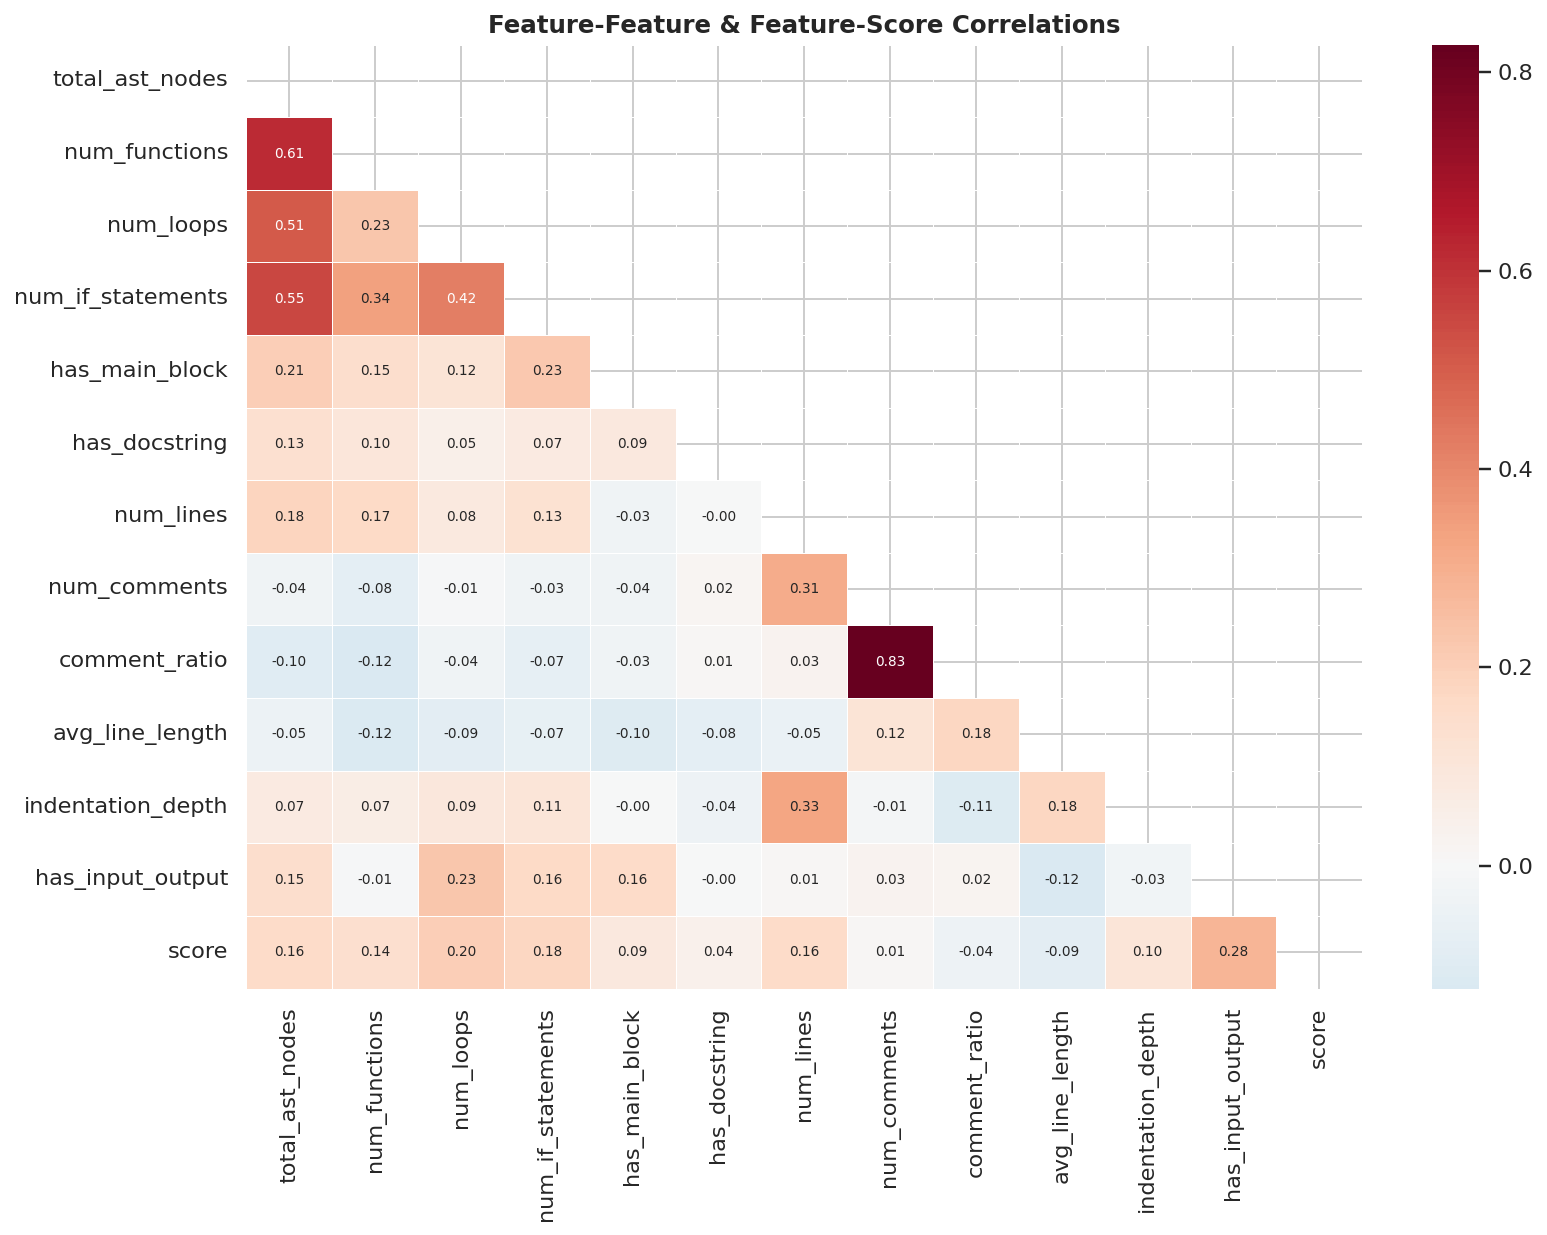

  saved -> /content/figures/eda_correlation_heatmap.png


In [ ]:
# Correlation heatmap
fig, ax = plt.subplots(figsize=(12, 9))
corr = X_all.assign(score=df["score"]).corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", ax=ax,
            cmap="RdBu_r", center=0, linewidths=.3, annot_kws={"size": 7})
ax.set_title("Feature-Feature & Feature-Score Correlations", fontweight="bold")
plt.tight_layout()
savefig("eda_correlation_heatmap.png")


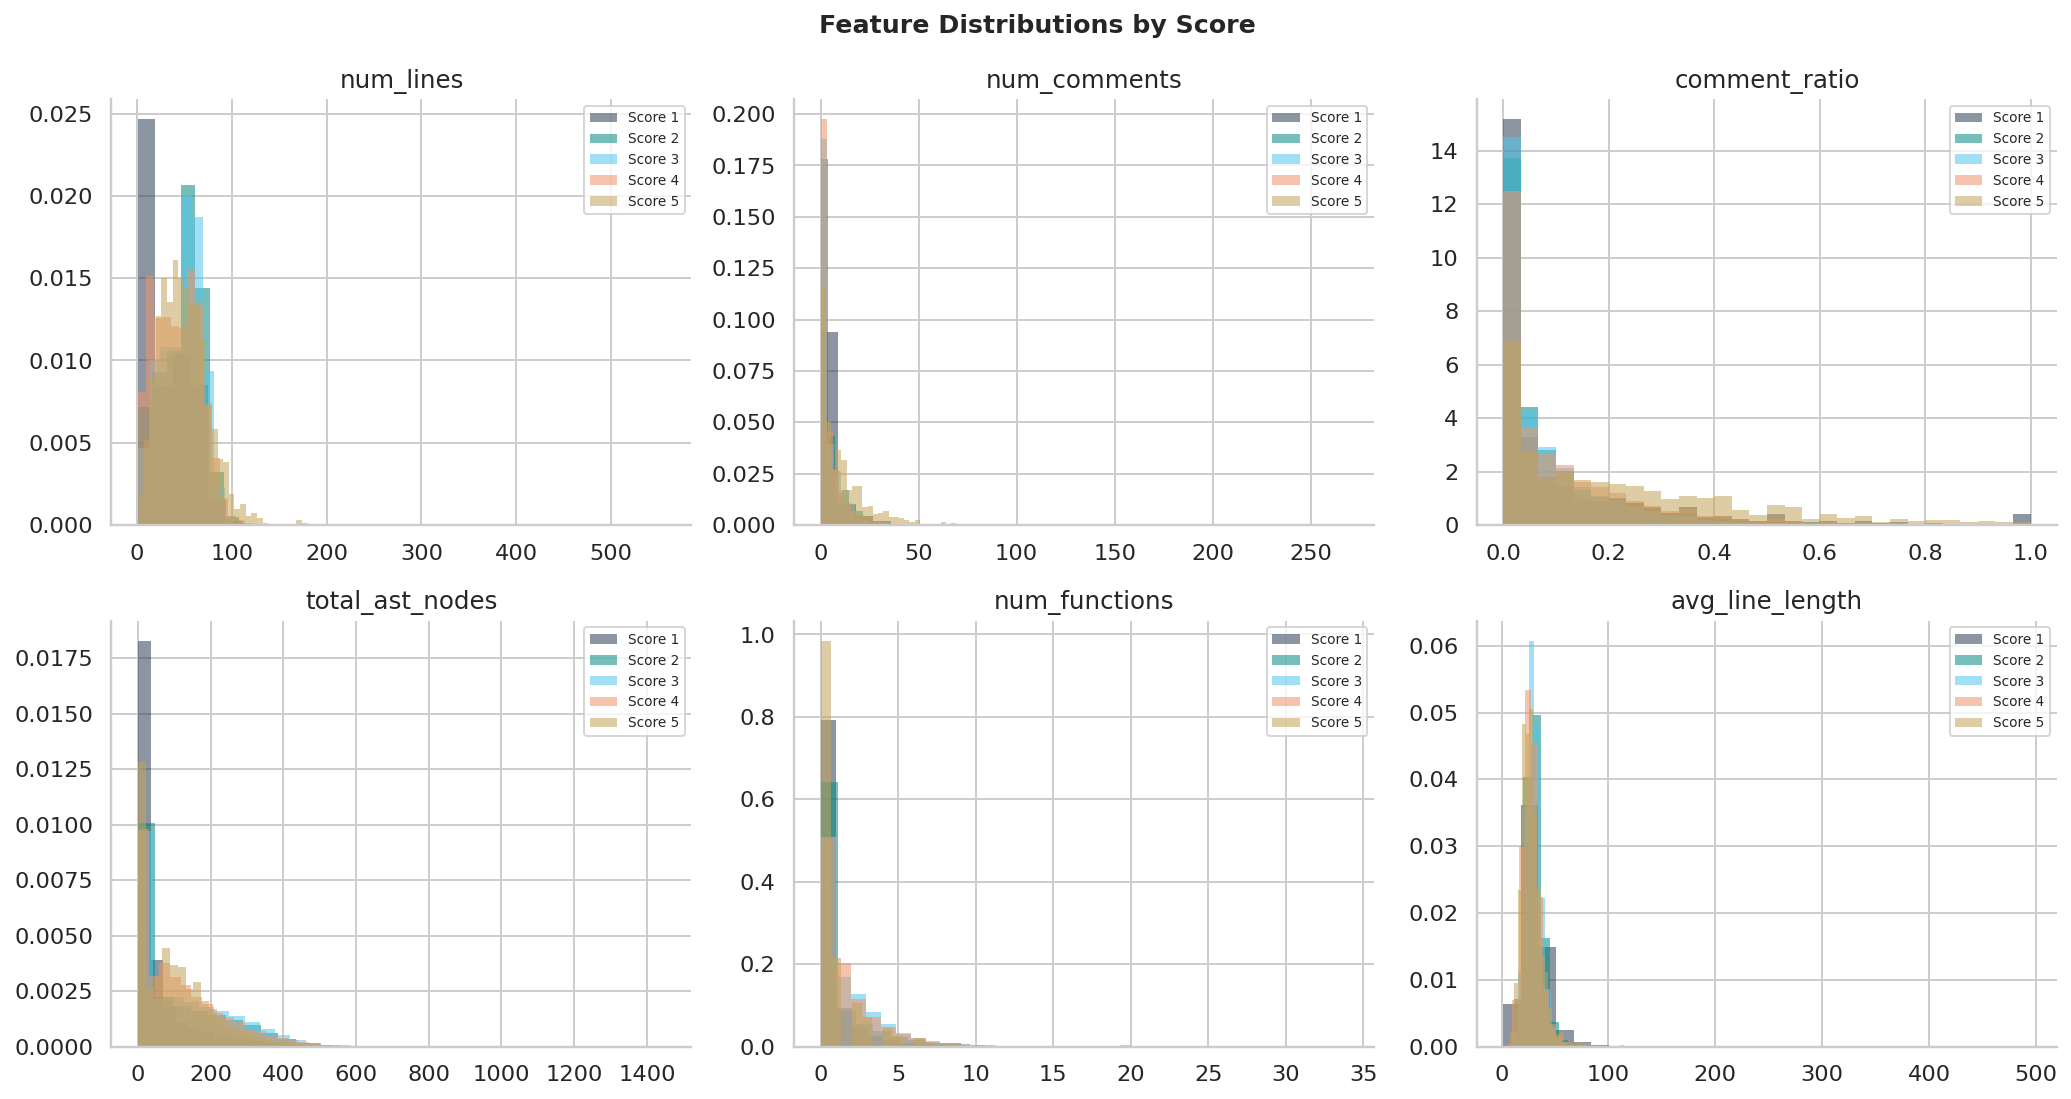

  saved -> /content/figures/eda_feature_distributions.png
EDA done.


In [ ]:
# Feature distributions by score
plot_cols = ["num_lines","num_comments","comment_ratio",
             "total_ast_nodes","num_functions","avg_line_length"]
Xd = X_all[plot_cols].assign(score=df["score"])
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle("Feature Distributions by Score", fontweight="bold", fontsize=13)
for ax, col in zip(axes.flat, plot_cols):
    for sc, color in zip(range(1,6), PALETTE):
        vals = Xd.loc[Xd["score"]==sc, col]
        ax.hist(vals, bins=30, alpha=0.55, label=f"Score {sc}",
                color=color, edgecolor="none", density=True)
    ax.set_title(col); ax.legend(fontsize=7)
plt.tight_layout()
savefig("eda_feature_distributions.png")
print("EDA done.")


## Experiment 2 — Baseline (All Features, All Models)

Loading Exp 2 results from Drive cache...
  Loaded <- /content/drive/MyDrive/file1_cache/exp2_baseline.json
  Loaded 3 results.
  LogisticRegression    Accuracy=0.3647  Macro-F1=0.2934
  RandomForest          Accuracy=0.4609  Macro-F1=0.3497
  XGBoost               Accuracy=0.4410  Macro-F1=0.3675


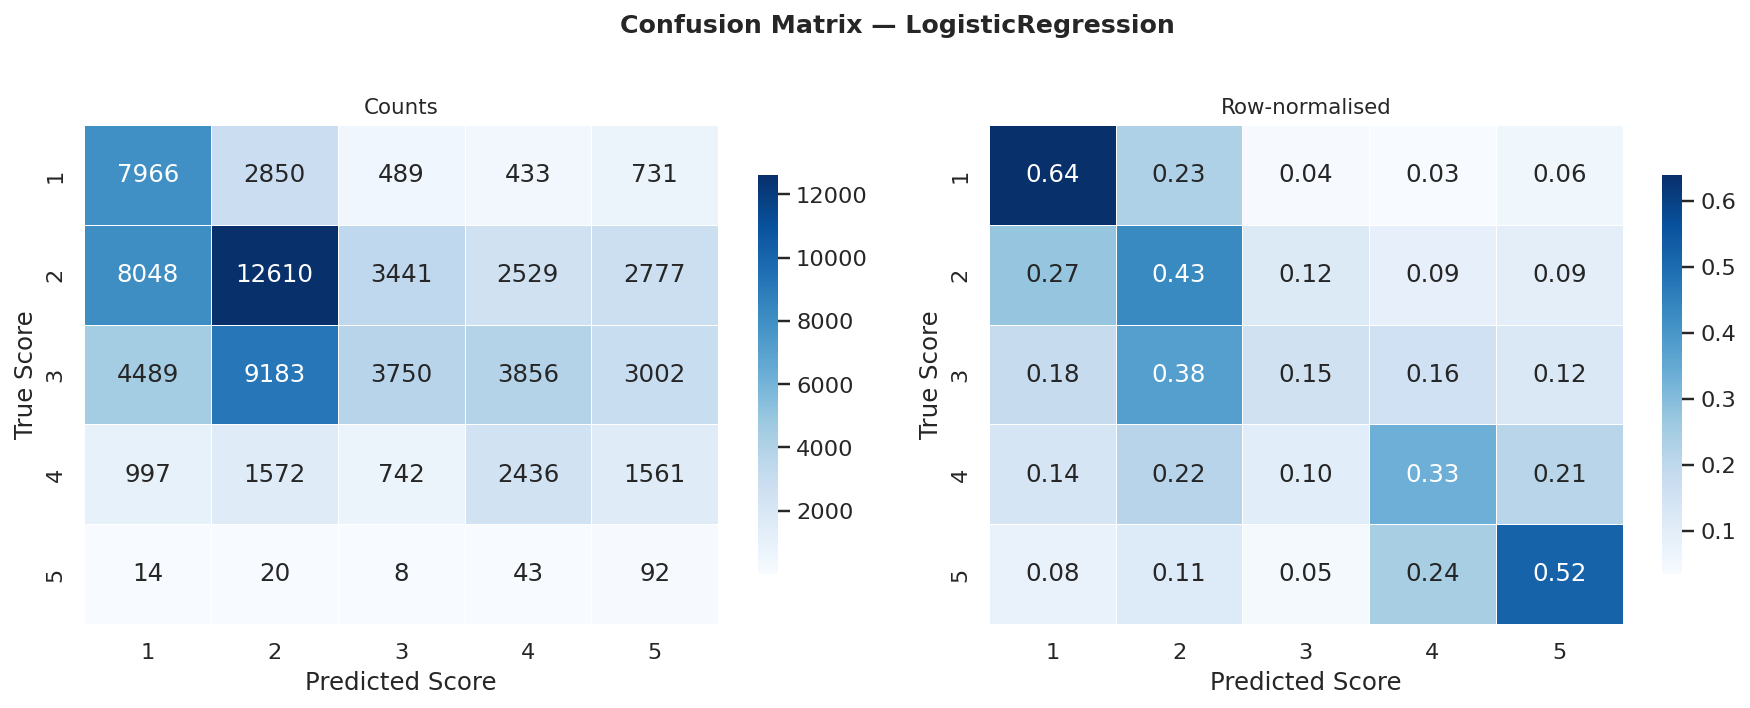

  saved -> /content/figures/exp2_cm_logisticregression.png


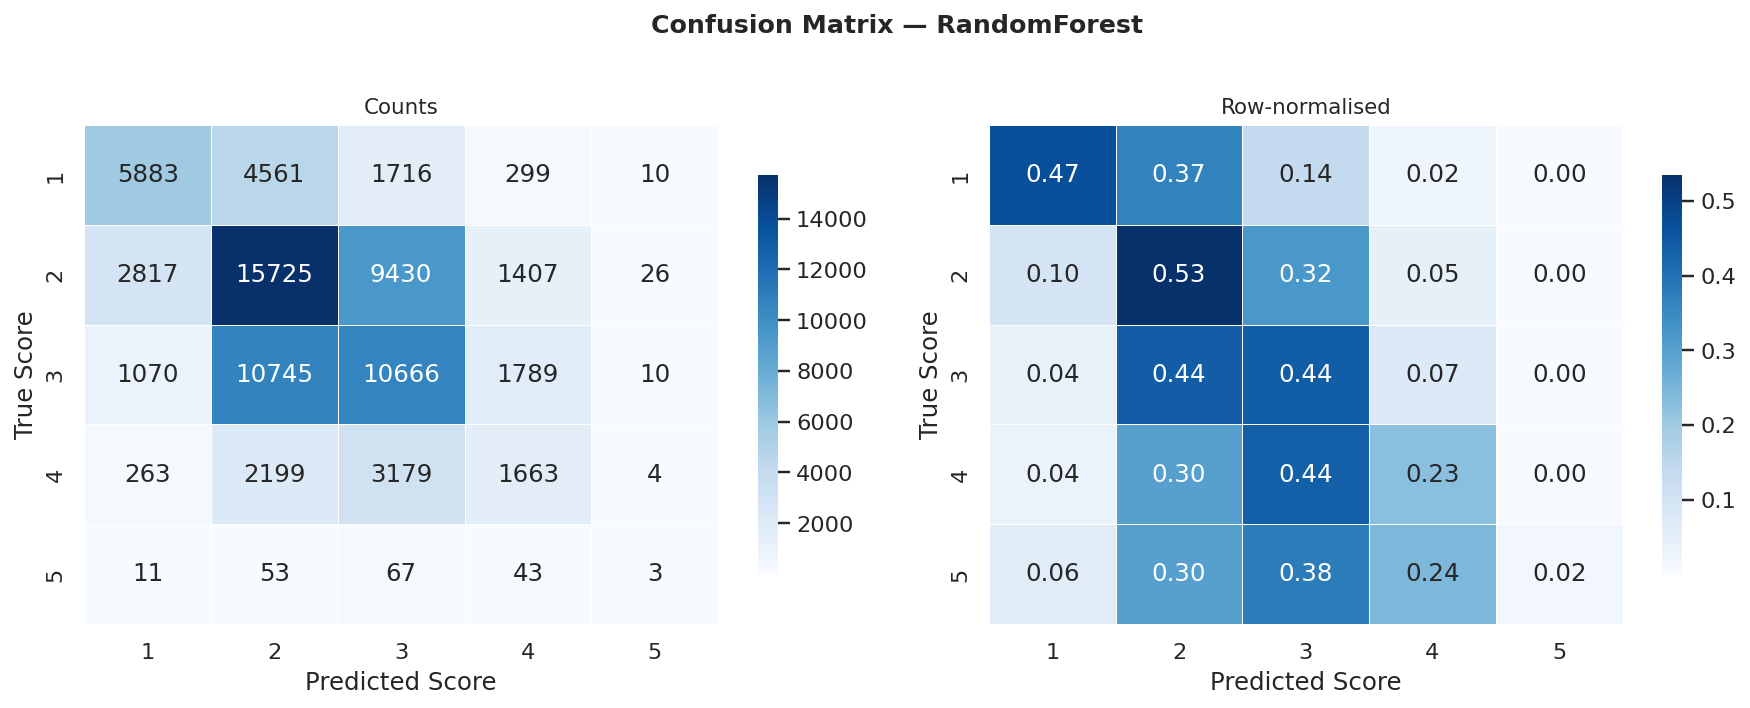

  saved -> /content/figures/exp2_cm_randomforest.png


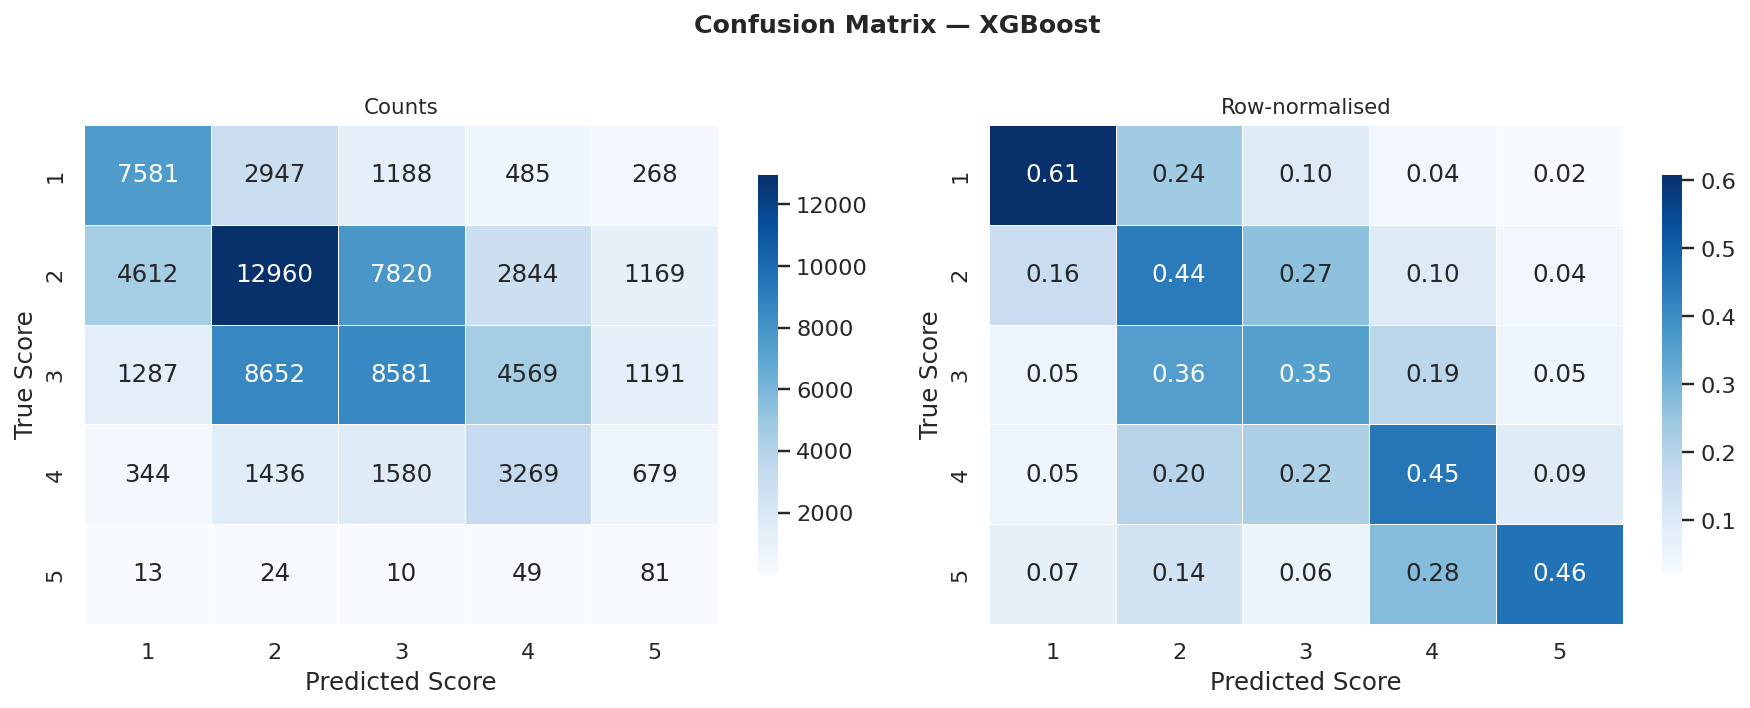

  saved -> /content/figures/exp2_cm_xgboost.png


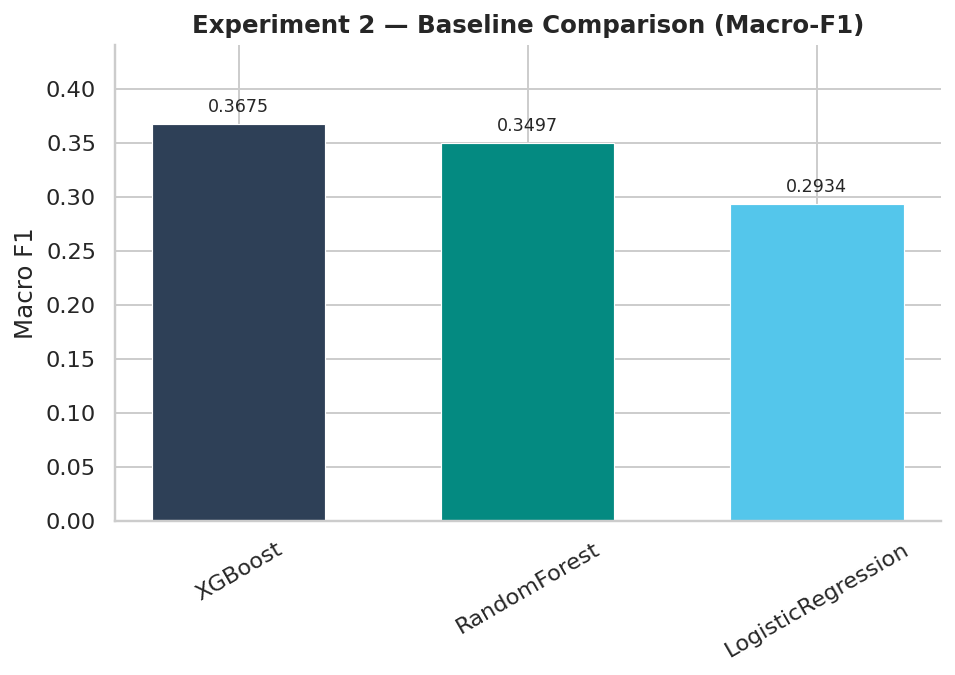

  saved -> /content/figures/exp2_baseline_f1.png


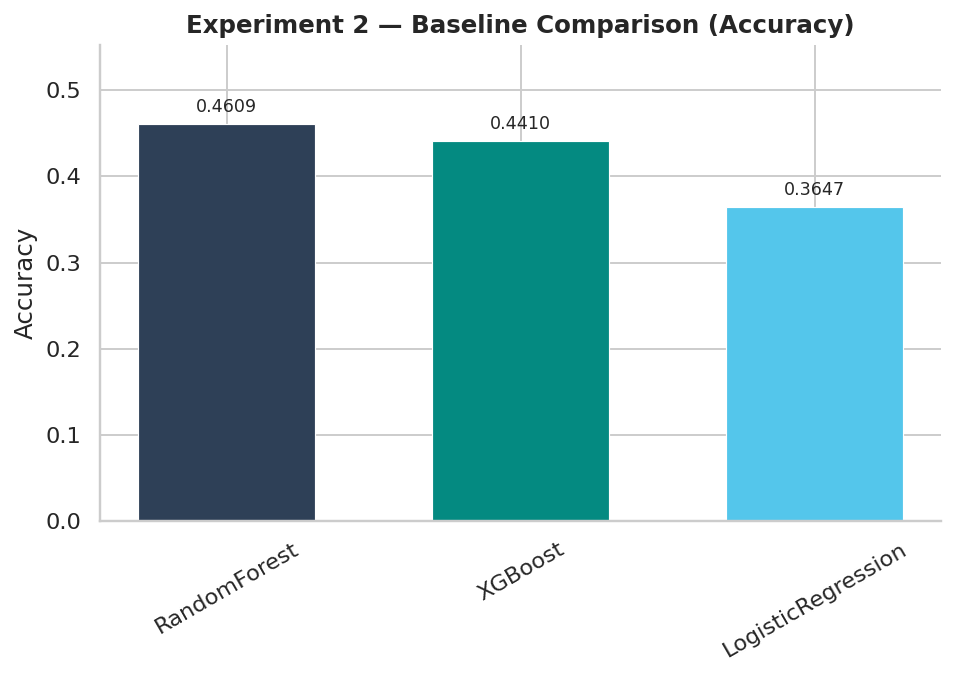

  saved -> /content/figures/exp2_baseline_acc.png


In [ ]:
EXP2_CACHE = "exp2_baseline.json"

if is_cached(EXP2_CACHE):
    print("Loading Exp 2 results from Drive cache...")
    baseline_results = load_json(EXP2_CACHE)
    print(f"  Loaded {len(baseline_results)} results.")
    for r in baseline_results:
        print(f"  {r['label']:20s}  Accuracy={r['accuracy']:.4f}  Macro-F1={r['macro_f1']:.4f}")
else:
    print("[Experiment 2] Baseline — all features, all models")
    baseline_results = []
    for name in MODELS:
        print(f"  Training {name}...", flush=True)
        y_pred, model = fit_predict(name, X_tr_all, y_tr, X_te_all)
        m = evaluate(y_te, y_pred)
        m["label"] = name
        baseline_results.append(m)
        print(f"    Accuracy={m['accuracy']:.4f}  Macro-F1={m['macro_f1']:.4f}")
        print(textwrap.indent(classification_report(y_te, y_pred, zero_division=0), "    "))
        if name == "RandomForest":
            feature_importance_plot(model.feature_importances_, feature_names,
                                    "Random Forest — Feature Importance",
                                    "exp2_fi_randomforest.png")
        elif name == "XGBoost":
            feature_importance_plot(model.feature_importances_, feature_names,
                                    "XGBoost — Feature Importance",
                                    "exp2_fi_xgboost.png")
    save_json(EXP2_CACHE, baseline_results)

# Always regenerate plots
for r in baseline_results:
    plot_confusion_matrix(r["cm"], f"Confusion Matrix — {r['label']}",
                          f"exp2_cm_{r['label'].lower()}.png")
bar_comparison(baseline_results, "macro_f1",
               "Experiment 2 — Baseline Comparison (Macro-F1)", "exp2_baseline_f1.png")
bar_comparison(baseline_results, "accuracy",
               "Experiment 2 — Baseline Comparison (Accuracy)", "exp2_baseline_acc.png")


## Experiment 3 — Ablation (Feature Groups)

Loading ablation feature matrices from Drive cache...
  Loaded <- /content/drive/MyDrive/file1_cache/exp3_feat_matrices.npz
Loading Exp 3 results from Drive cache...
  Loaded <- /content/drive/MyDrive/file1_cache/exp3_ablation.json
  Loaded 8 results.


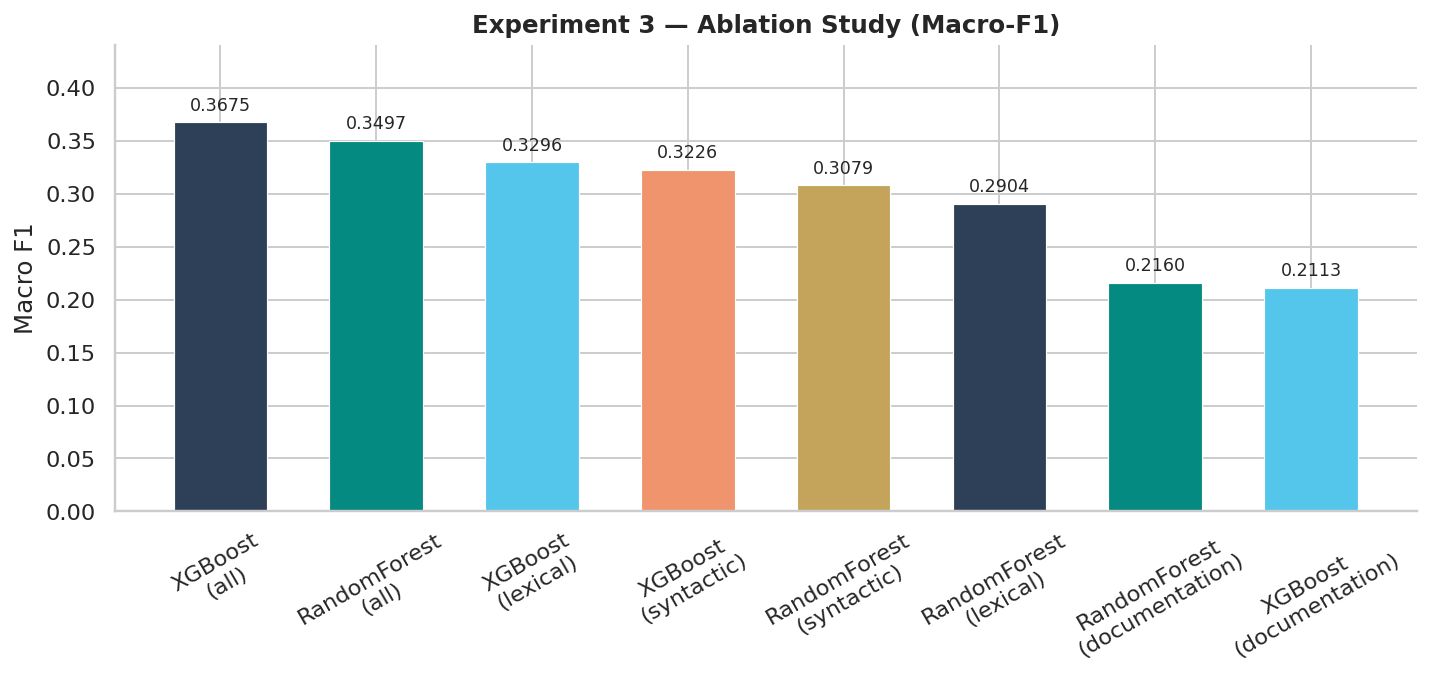

  saved -> /content/figures/exp3_ablation.png


In [ ]:
EXP3_FEAT_CACHE = "exp3_feat_matrices.npz"
EXP3_RES_CACHE  = "exp3_ablation.json"

configs = {
    "documentation": doc_features,
    "lexical":       lexical_features,
    "syntactic":     syntactic_features,
    "all":           all_features,
}

# Load or extract per-group feature matrices
if is_cached(EXP3_FEAT_CACHE):
    print("Loading ablation feature matrices from Drive cache...")
    cache      = load_npz(EXP3_FEAT_CACHE)
    feat_mats  = {name: {"tr": cache[f"{name}_tr"], "te": cache[f"{name}_te"]}
                  for name in configs}
else:
    feat_mats, save_dict = {}, {}
    for name in configs:
        print(f"  Extracting [{name}]...")
        tr = build_feature_matrix(df_train, name).values
        te = build_feature_matrix(df_test,  name).values
        feat_mats[name] = {"tr": tr, "te": te}
        save_dict[f"{name}_tr"] = tr
        save_dict[f"{name}_te"] = te
    save_npz(EXP3_FEAT_CACHE, **save_dict)

# Load or run models
if is_cached(EXP3_RES_CACHE):
    print("Loading Exp 3 results from Drive cache...")
    ablation_results = load_json(EXP3_RES_CACHE)
    print(f"  Loaded {len(ablation_results)} results.")
else:
    print("[Experiment 3] Ablation — documentation | lexical | syntactic | all")
    ablation_results = []
    for fname_set in configs:
        Xtr = feat_mats[fname_set]["tr"]
        Xte = feat_mats[fname_set]["te"]
        for model_name in ["RandomForest", "XGBoost"]:
            print(f"  {model_name} / {fname_set}...", flush=True)
            y_pred, _ = fit_predict(model_name, Xtr, y_tr, Xte)
            m = evaluate(y_te, y_pred)
            m["label"]       = f"{model_name}\n({fname_set})"
            m["feature_set"] = fname_set
            m["model"]       = model_name
            ablation_results.append(m)
            print(f"    Macro-F1={m['macro_f1']:.4f}")
    save_json(EXP3_RES_CACHE, ablation_results)

bar_comparison(ablation_results, "macro_f1",
               "Experiment 3 — Ablation Study (Macro-F1)", "exp3_ablation.png")


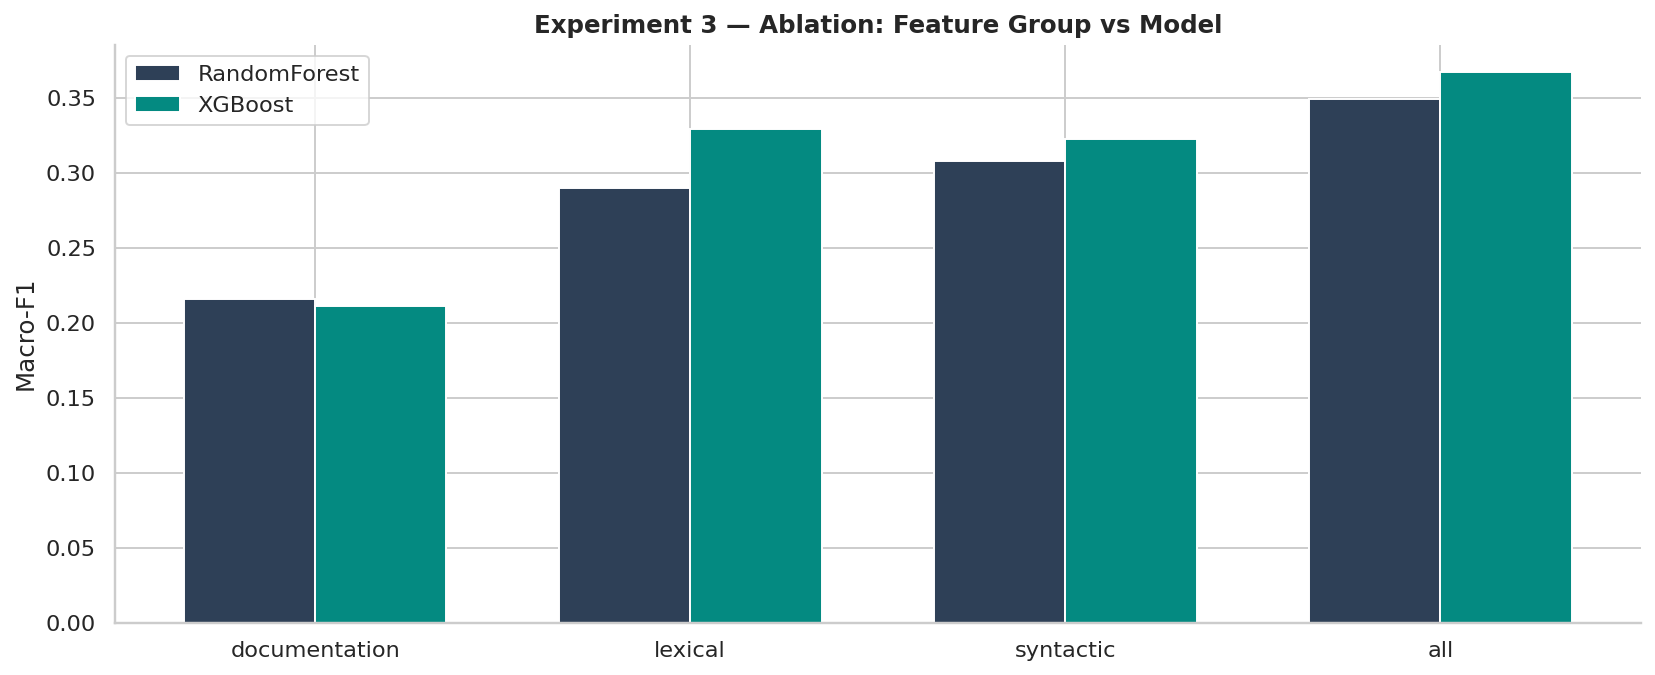

  saved -> /content/figures/exp3_ablation_grouped.png


In [ ]:
# Grouped bar
df_abl = pd.DataFrame(ablation_results)
fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(configs)); w = 0.35
for i, mn in enumerate(["RandomForest", "XGBoost"]):
    subset = df_abl[df_abl["model"]==mn].set_index("feature_set")
    vals   = [subset.loc[fs,"macro_f1"] if fs in subset.index else 0 for fs in configs]
    ax.bar(x + i*w, vals, w, label=mn, color=PALETTE[i], edgecolor="white")
ax.set_xticks(x + w/2); ax.set_xticklabels(list(configs.keys()))
ax.set_ylabel("Macro-F1"); ax.legend()
ax.set_title("Experiment 3 — Ablation: Feature Group vs Model", fontweight="bold")
plt.tight_layout()
savefig("exp3_ablation_grouped.png")


## Experiment 4 — Training Size Sensitivity

Loading Exp 4 results from Drive cache...
  Loaded <- /content/drive/MyDrive/file1_cache/exp4_training_size.json
  Loaded 6 results.


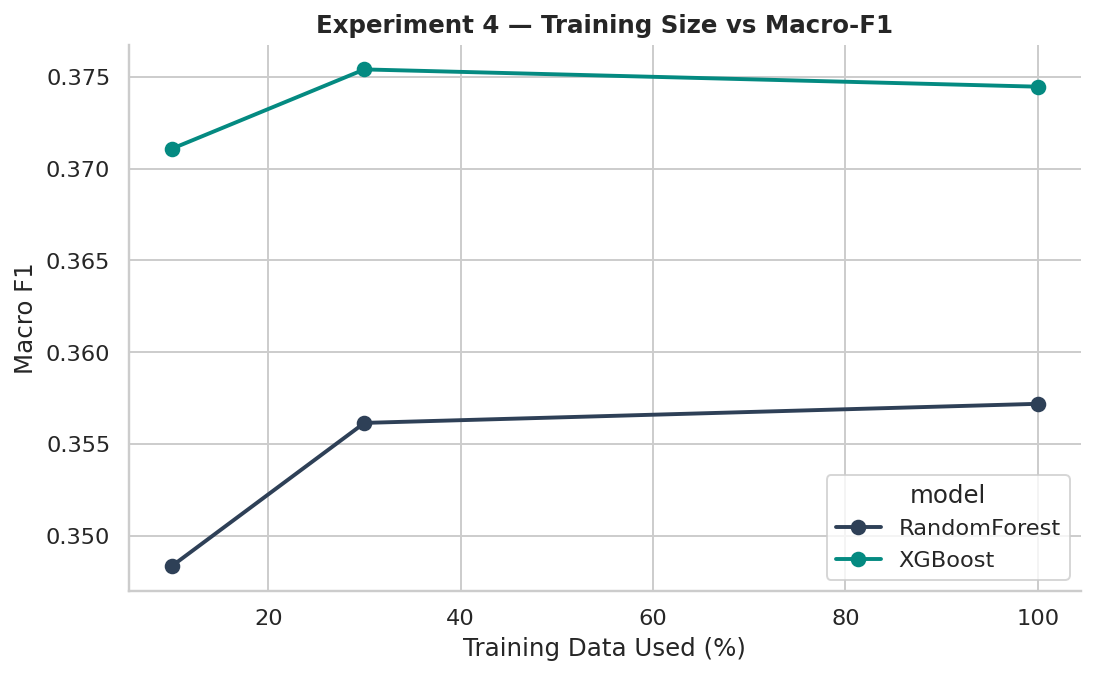

  saved -> /content/figures/exp4_training_size_curve.png


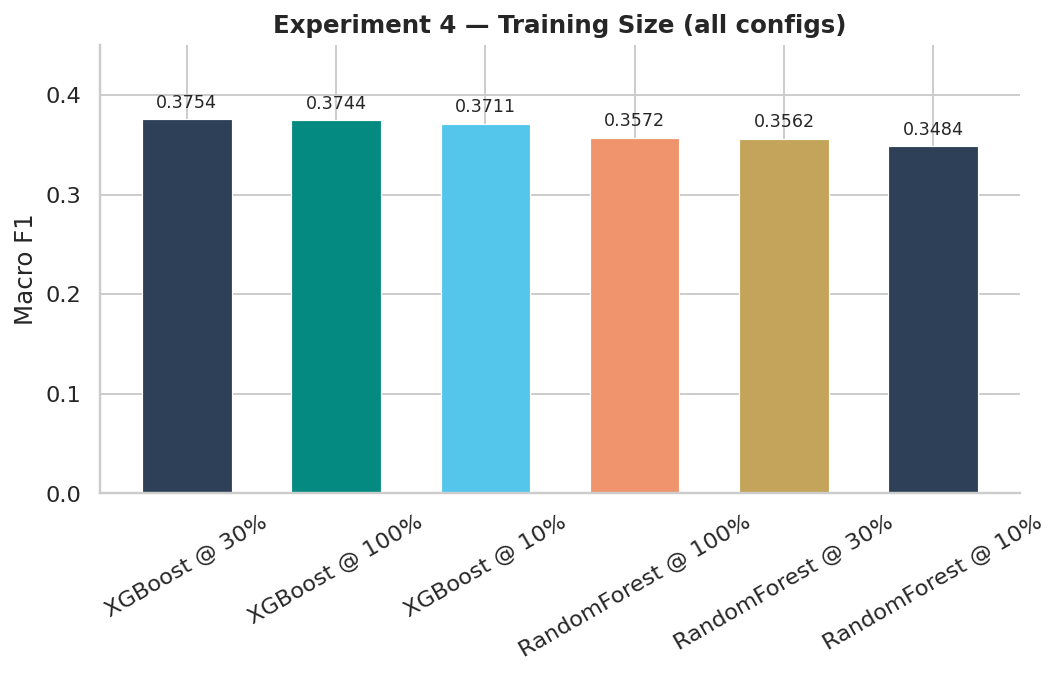

  saved -> /content/figures/exp4_training_size_bar.png


In [ ]:
EXP4_CACHE = "exp4_training_size.json"

if is_cached(EXP4_CACHE):
    print("Loading Exp 4 results from Drive cache...")
    train_size_results = load_json(EXP4_CACHE)
    print(f"  Loaded {len(train_size_results)} results.")
else:
    print("[Experiment 4] Training size — 10% / 30% / 100%")
    train_size_results = []
    for frac in [0.10, 0.30, 1.00]:
        frames = [g.sample(frac=frac, random_state=42) for _, g in df_train.groupby("score")]
        sub    = pd.concat(frames).reset_index(drop=True)
        Xtr    = build_feature_matrix(sub, "all").values
        ytr    = sub["score"].values
        for model_name in ["RandomForest", "XGBoost"]:
            print(f"  {model_name} @ {frac*100:.0f}%  (n={len(sub):,})...", flush=True)
            y_pred, _ = fit_predict(model_name, Xtr, ytr, X_te_all)
            m = evaluate(y_te, y_pred)
            m["label"]    = f"{model_name} @ {frac*100:.0f}%"
            m["fraction"] = frac * 100
            m["model"]    = model_name
            train_size_results.append(m)
            print(f"    Macro-F1={m['macro_f1']:.4f}")
    save_json(EXP4_CACHE, train_size_results)

line_chart(train_size_results, "fraction", "macro_f1", "model",
           "Experiment 4 — Training Size vs Macro-F1",
           "exp4_training_size_curve.png", xlabel="Training Data Used (%)")
bar_comparison(train_size_results, "macro_f1",
               "Experiment 4 — Training Size (all configs)",
               "exp4_training_size_bar.png")


## Experiment 5 — Documentation Feature Impact

Loading Exp 5 feature matrices from Drive cache...
  Loaded <- /content/drive/MyDrive/file1_cache/exp5_doc_feat_matrices.npz
Loading Exp 5 results from Drive cache...
  Loaded <- /content/drive/MyDrive/file1_cache/exp5_doc_impact.json
  Loaded 4 results.


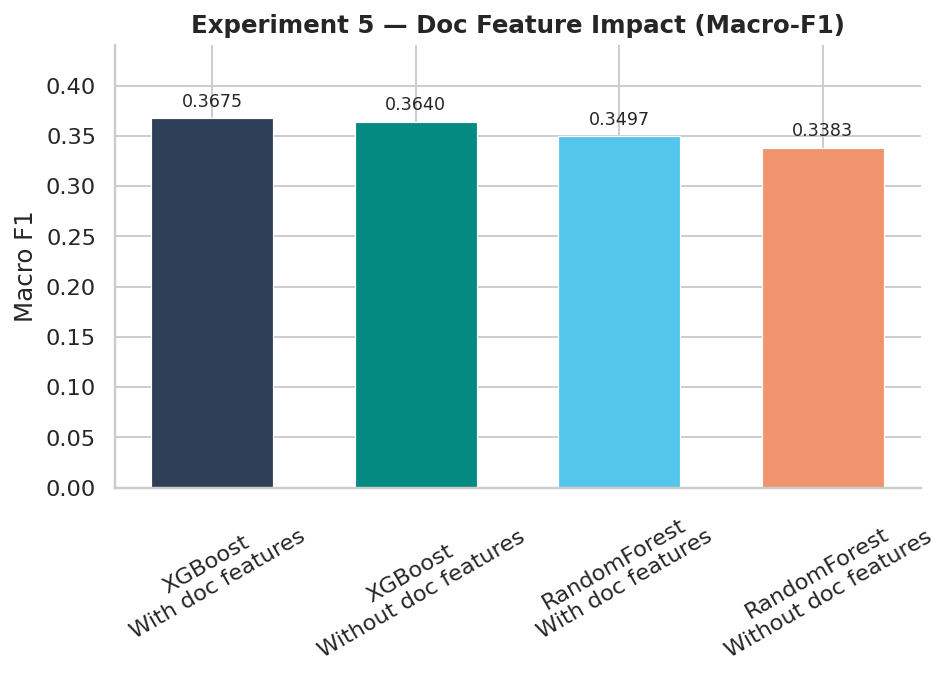

  saved -> /content/figures/exp5_doc_impact.png


In [ ]:
EXP5_FEAT_CACHE = "exp5_doc_feat_matrices.npz"
EXP5_RES_CACHE  = "exp5_doc_impact.json"

non_doc_features = lexical_features + syntactic_features

# Load or extract feature matrices
if is_cached(EXP5_FEAT_CACHE):
    print("Loading Exp 5 feature matrices from Drive cache...")
    cache    = load_npz(EXP5_FEAT_CACHE)
    X_with_tr   = cache["X_with_tr"]
    X_with_te   = cache["X_with_te"]
    X_without_tr = cache["X_without_tr"]
    X_without_te = cache["X_without_te"]
else:
    print("Extracting doc impact feature matrices...")
    X_with_tr    = build_feature_matrix_custom(df_train, all_features).values
    X_with_te    = build_feature_matrix_custom(df_test,  all_features).values
    X_without_tr = build_feature_matrix_custom(df_train, non_doc_features).values
    X_without_te = build_feature_matrix_custom(df_test,  non_doc_features).values
    save_npz(EXP5_FEAT_CACHE,
             X_with_tr=X_with_tr,    X_with_te=X_with_te,
             X_without_tr=X_without_tr, X_without_te=X_without_te)

# Load or run models
if is_cached(EXP5_RES_CACHE):
    print("Loading Exp 5 results from Drive cache...")
    doc_impact_results = load_json(EXP5_RES_CACHE)
    print(f"  Loaded {len(doc_impact_results)} results.")
else:
    print("[Experiment 5] Doc feature impact — with vs without documentation features")
    doc_impact_results = []
    for include, Xtr, Xte in [(True, X_with_tr, X_with_te),
                               (False, X_without_tr, X_without_te)]:
        label = "With doc features" if include else "Without doc features"
        for model_name in ["RandomForest", "XGBoost"]:
            print(f"  {model_name} / {label}...", flush=True)
            y_pred, _ = fit_predict(model_name, Xtr, y_tr, Xte)
            m = evaluate(y_te, y_pred)
            m["label"] = f"{model_name}\n{label}"
            m["model"] = model_name
            m["doc"]   = include
            doc_impact_results.append(m)
            print(f"    Macro-F1={m['macro_f1']:.4f}")
    save_json(EXP5_RES_CACHE, doc_impact_results)

bar_comparison(doc_impact_results, "macro_f1",
               "Experiment 5 — Doc Feature Impact (Macro-F1)", "exp5_doc_impact.png")


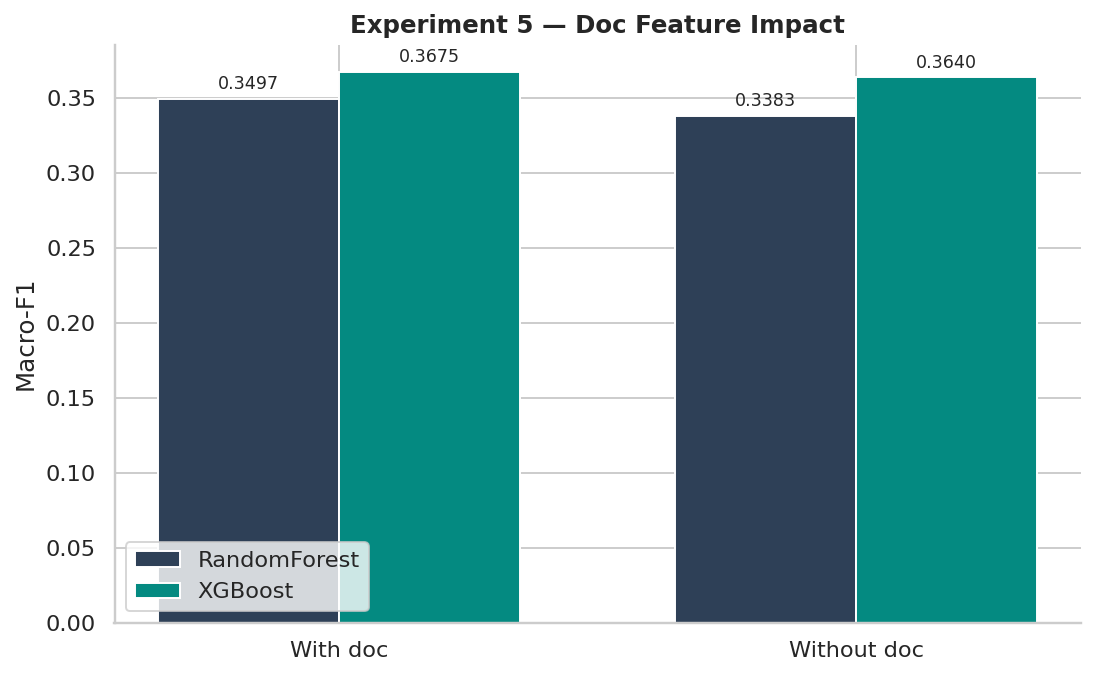

  saved -> /content/figures/exp5_doc_grouped.png


In [ ]:
# Grouped view
df_doc = pd.DataFrame(doc_impact_results)
fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(2); w = 0.35
for i, mn in enumerate(["RandomForest", "XGBoost"]):
    sub  = df_doc[df_doc["model"]==mn]
    vals = [sub[sub["doc"]==d]["macro_f1"].values[0] for d in [True, False]]
    ax.bar(x + i*w, vals, w, label=mn, color=PALETTE[i], edgecolor="white")
ax.bar_label(ax.containers[0], fmt="%.4f", padding=3, fontsize=9)
ax.bar_label(ax.containers[1], fmt="%.4f", padding=3, fontsize=9)
ax.set_xticks(x + w/2); ax.set_xticklabels(["With doc", "Without doc"])
ax.set_ylabel("Macro-F1"); ax.legend()
ax.set_title("Experiment 5 — Doc Feature Impact", fontweight="bold")
plt.tight_layout()
savefig("exp5_doc_grouped.png")


## Experiment 6 — Class Imbalance Strategies

Loading Exp 6 results from Drive cache...
  Loaded <- /content/drive/MyDrive/file1_cache/exp6_imbalance.json
  Loaded 4 results.


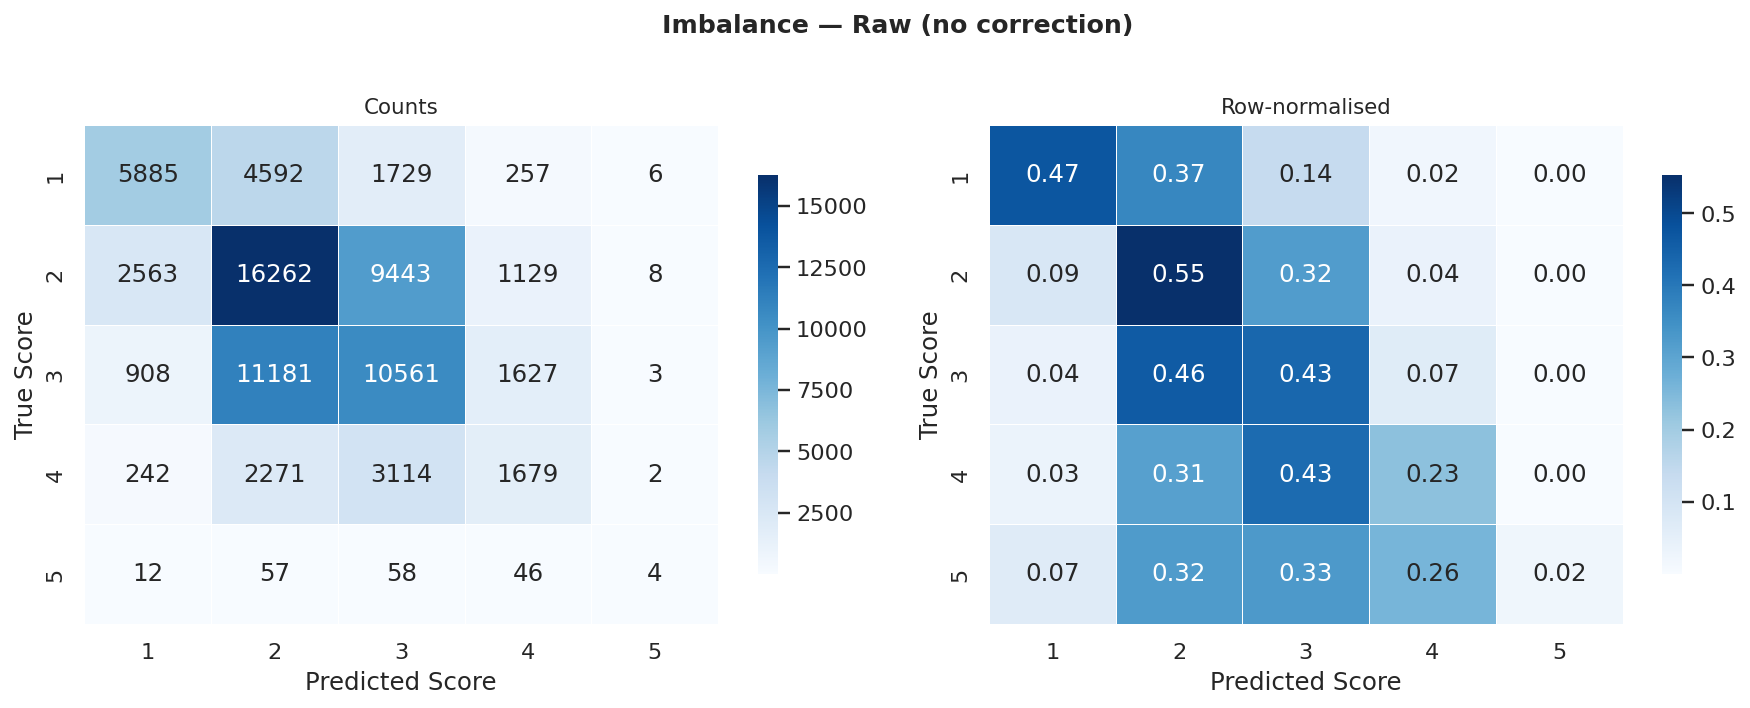

  saved -> /content/figures/exp6_cm_raw_(no_correction).png


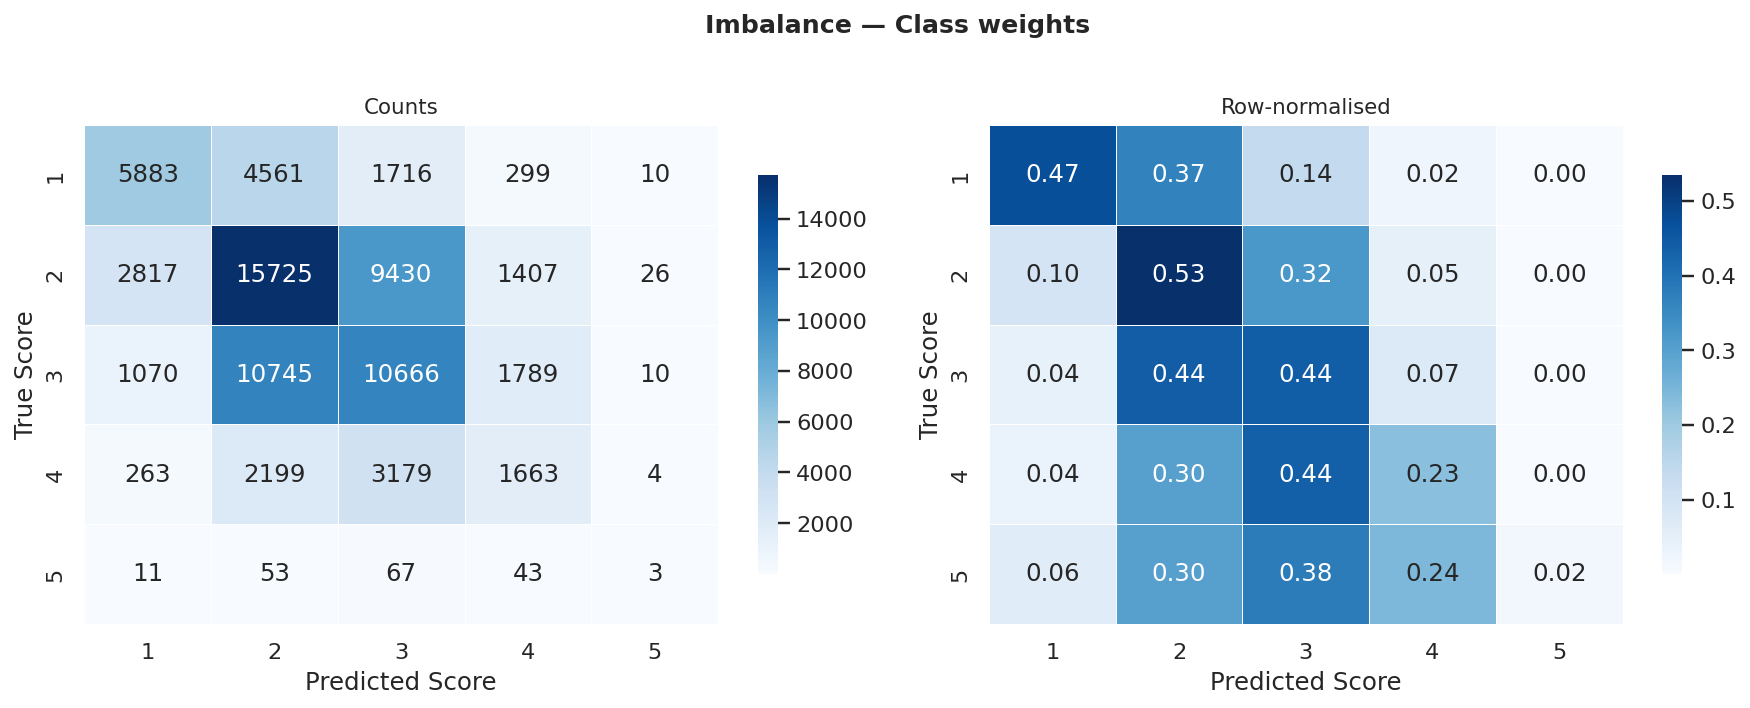

  saved -> /content/figures/exp6_cm_class_weights.png


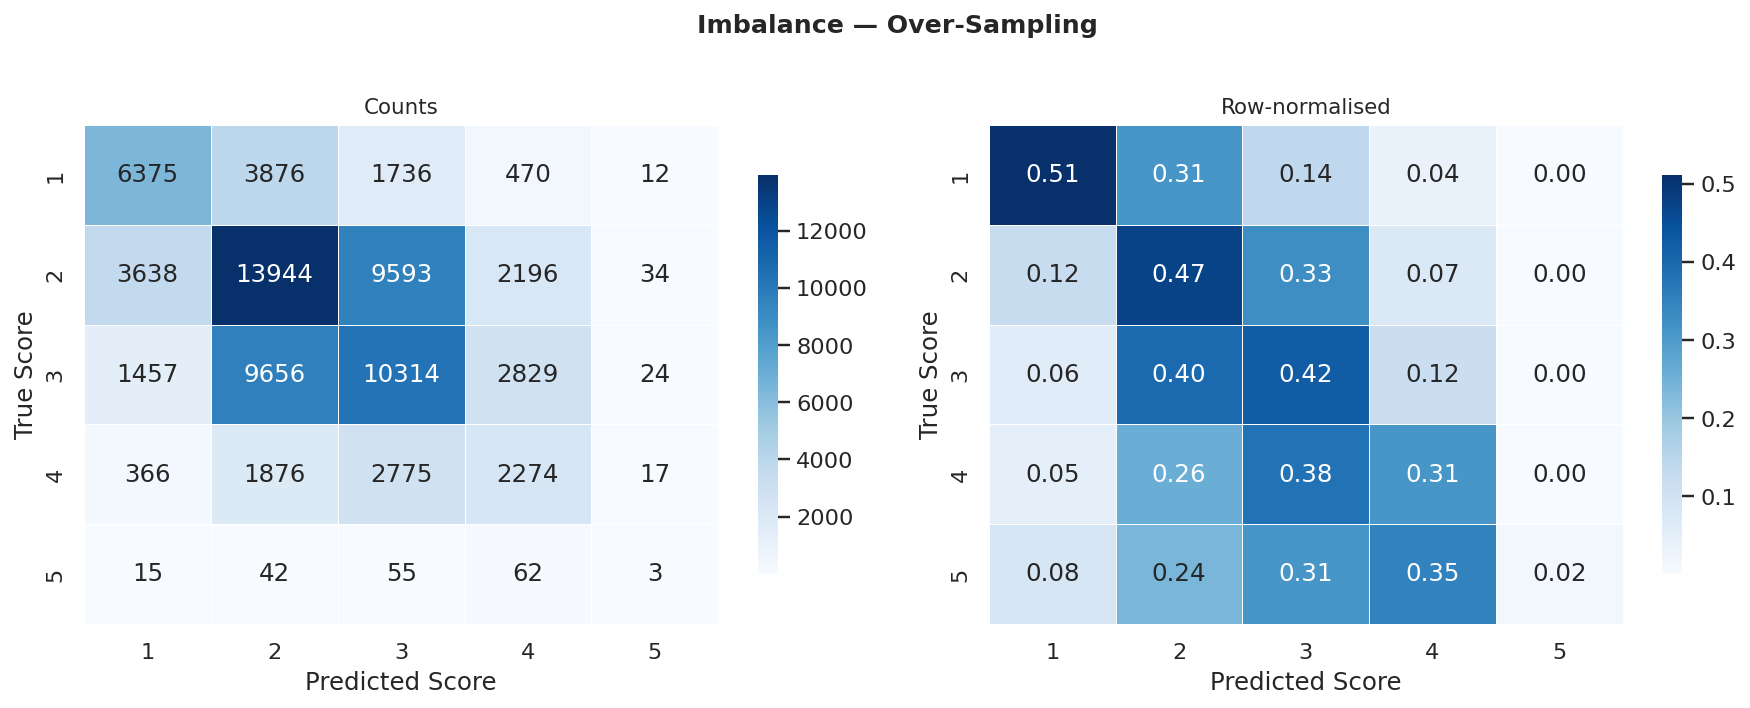

  saved -> /content/figures/exp6_cm_over-sampling.png


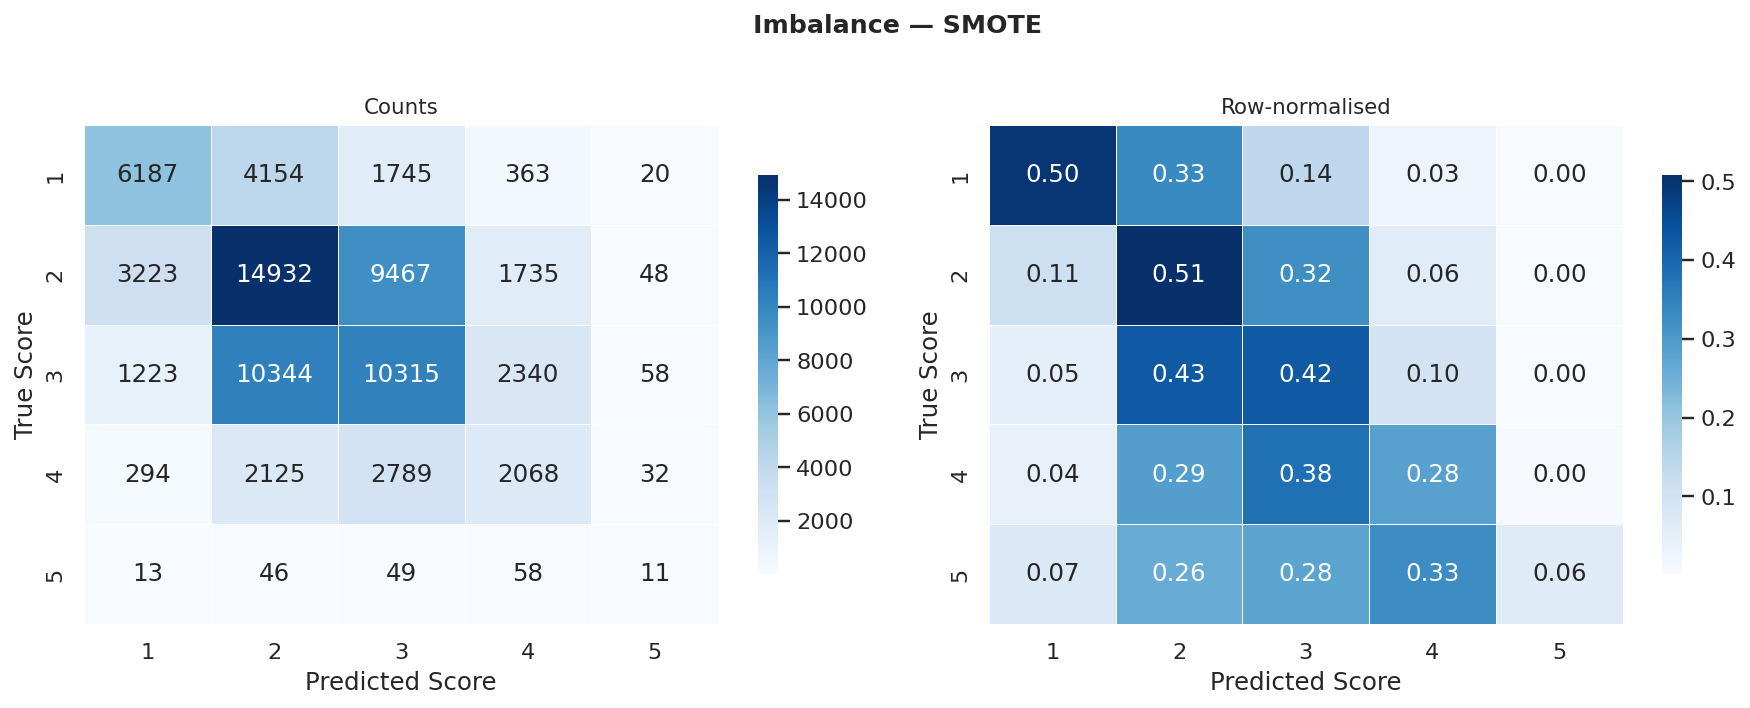

  saved -> /content/figures/exp6_cm_smote.png


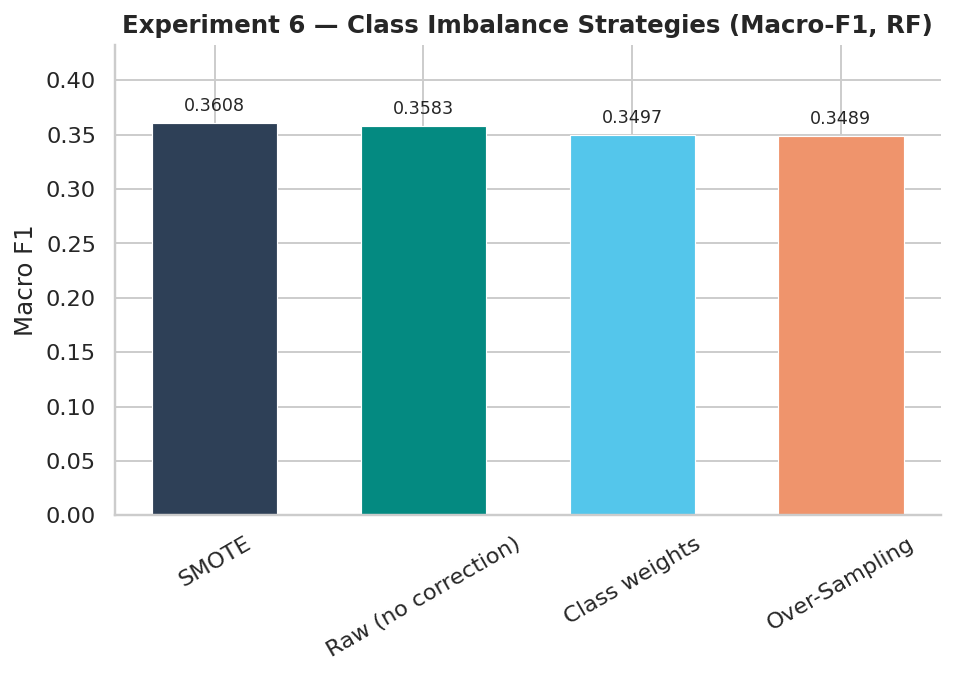

  saved -> /content/figures/exp6_imbalance.png


In [ ]:
EXP6_CACHE = "exp6_imbalance.json"

if is_cached(EXP6_CACHE):
    print("Loading Exp 6 results from Drive cache...")
    imbalance_results = load_json(EXP6_CACHE)
    print(f"  Loaded {len(imbalance_results)} results.")
else:
    print("[Experiment 6] Class imbalance — RF only")
    min_class = min(np.bincount(y_tr - 1))
    print(f"  Smallest class in train: {min_class}")

    strategies = {
        "Raw (no correction)": (X_tr_all, y_tr, None),
        "Class weights":       (X_tr_all, y_tr, "balanced"),
    }
    ros = RandomOverSampler(random_state=42)
    X_ros, y_ros = ros.fit_resample(X_tr_all, y_tr)
    strategies["Over-Sampling"] = (X_ros, y_ros, None)
    if min_class >= 6:
        smote = SMOTE(random_state=42, k_neighbors=min(5, min_class-1))
        X_sm, y_sm = smote.fit_resample(X_tr_all, y_tr)
        strategies["SMOTE"] = (X_sm, y_sm, None)
    else:
        print(f"  Skipping SMOTE — smallest class = {min_class}")

    imbalance_results = []
    for strat_name, (Xtr, ytr, cw) in strategies.items():
        print(f"  {strat_name}...", flush=True)
        model = build_rf(class_weight=cw or None)
        model.fit(Xtr, ytr)
        y_pred = model.predict(X_te_all)
        m = evaluate(y_te, y_pred)
        m["label"] = strat_name
        imbalance_results.append(m)
        print(f"    Macro-F1={m['macro_f1']:.4f}")
    save_json(EXP6_CACHE, imbalance_results)

for r in imbalance_results:
    plot_confusion_matrix(r["cm"],
                          f"Imbalance — {r['label']}",
                          f"exp6_cm_{r['label'].replace(' ','_').lower()}.png")
bar_comparison(imbalance_results, "macro_f1",
               "Experiment 6 — Class Imbalance Strategies (Macro-F1, RF)",
               "exp6_imbalance.png")


## Master Summary Table

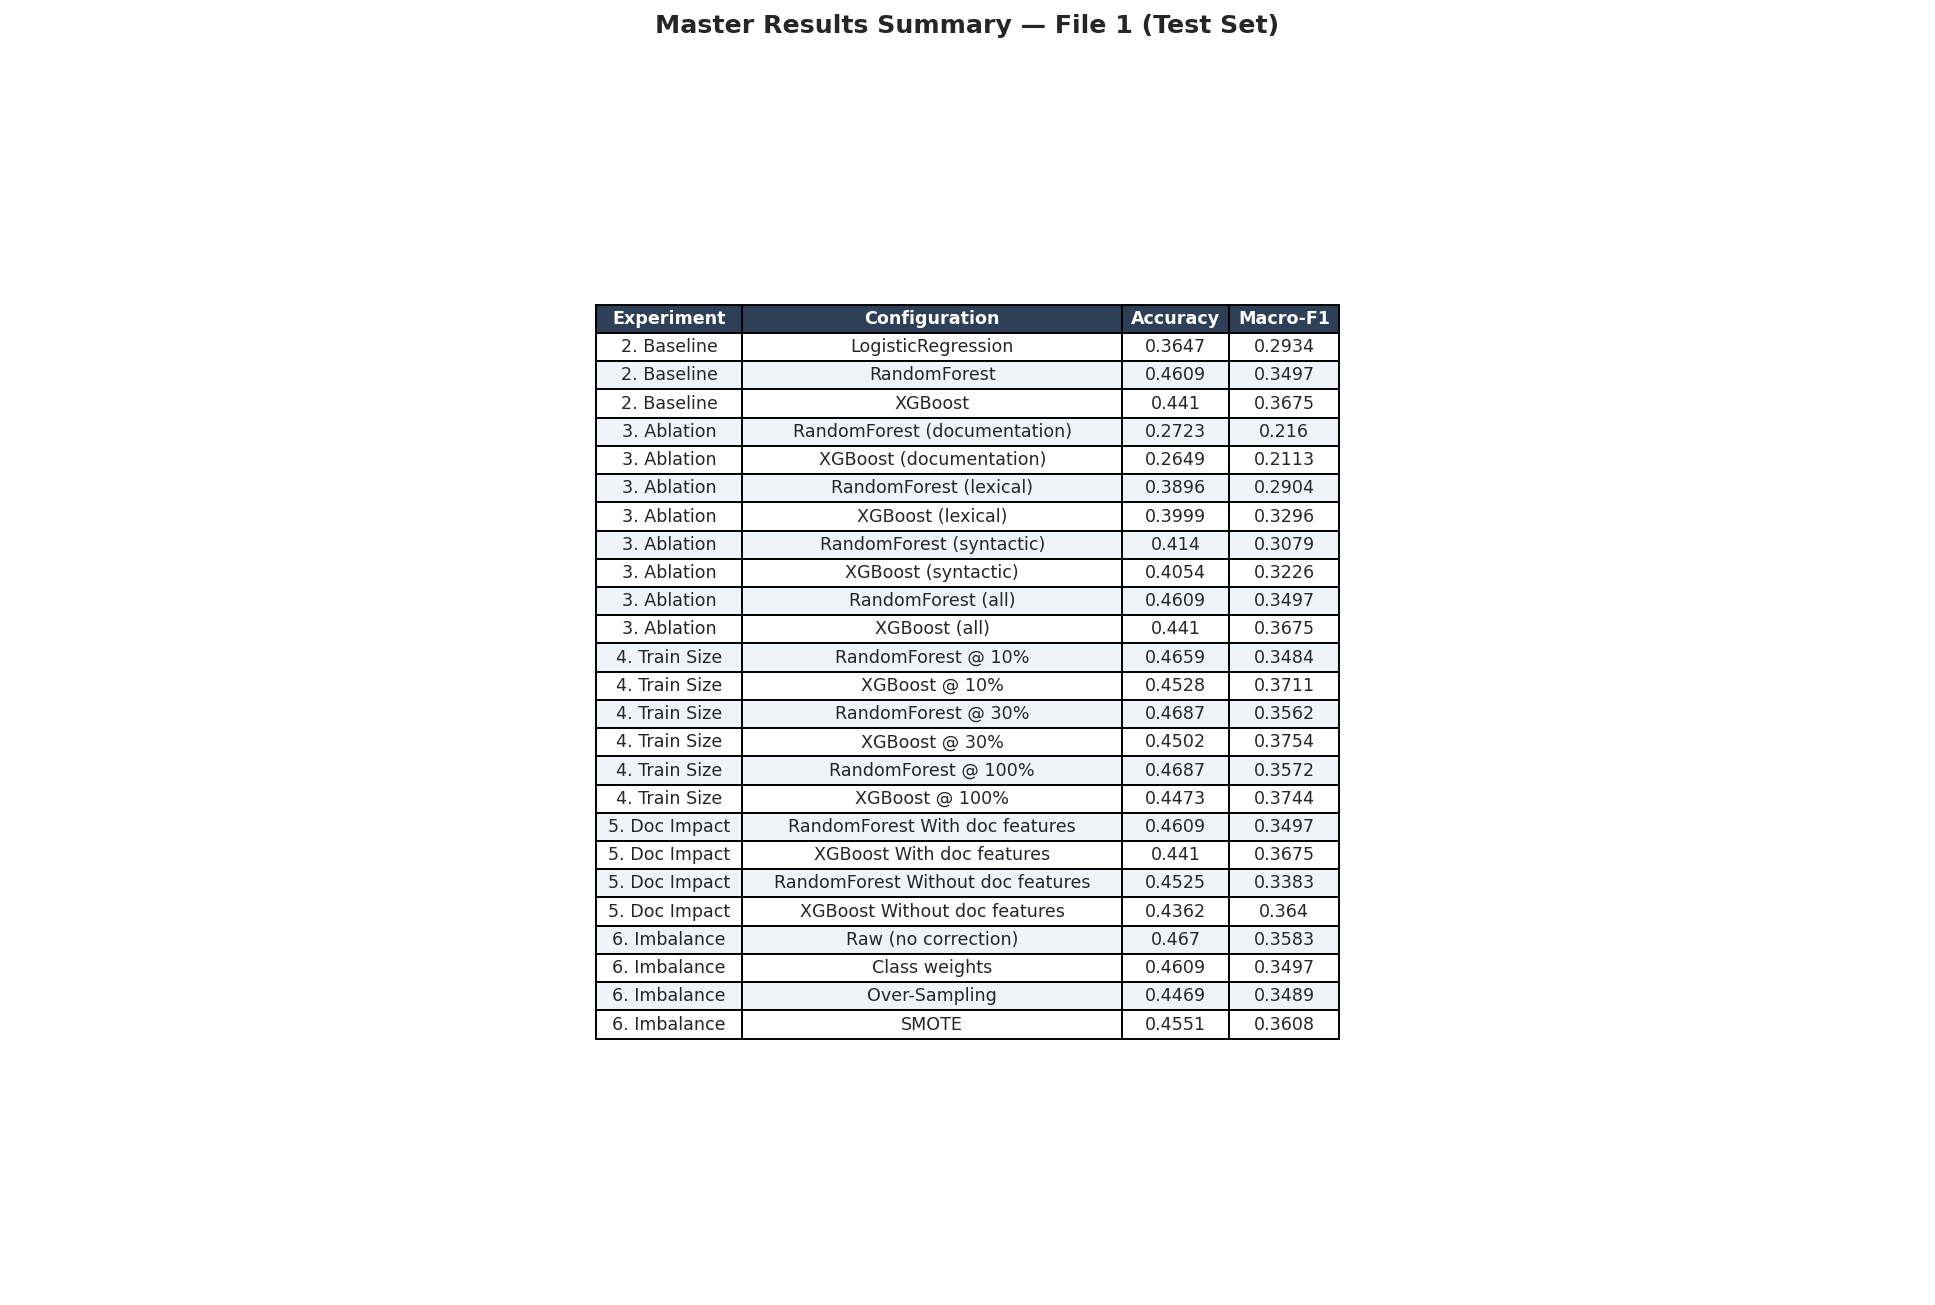

  saved -> /content/figures/master_summary_table.png
MASTER RESULTS SUMMARY
   Experiment                     Configuration  Accuracy  Macro-F1
  2. Baseline                LogisticRegression    0.3647    0.2934
  2. Baseline                      RandomForest    0.4609    0.3497
  2. Baseline                           XGBoost    0.4410    0.3675
  3. Ablation      RandomForest (documentation)    0.2723    0.2160
  3. Ablation           XGBoost (documentation)    0.2649    0.2113
  3. Ablation            RandomForest (lexical)    0.3896    0.2904
  3. Ablation                 XGBoost (lexical)    0.3999    0.3296
  3. Ablation          RandomForest (syntactic)    0.4140    0.3079
  3. Ablation               XGBoost (syntactic)    0.4054    0.3226
  3. Ablation                RandomForest (all)    0.4609    0.3497
  3. Ablation                     XGBoost (all)    0.4410    0.3675
4. Train Size                RandomForest @ 10%    0.4659    0.3484
4. Train Size                     XGBoos

In [ ]:
all_results = {
    "2. Baseline":   baseline_results,
    "3. Ablation":   ablation_results,
    "4. Train Size": train_size_results,
    "5. Doc Impact": doc_impact_results,
    "6. Imbalance":  imbalance_results,
}

rows = []
for exp, rlist in all_results.items():
    for r in rlist:
        rows.append({
            "Experiment":    exp,
            "Configuration": r.get("label","").replace("\n"," "),
            "Accuracy":      round(r["accuracy"], 4),
            "Macro-F1":      round(r["macro_f1"], 4),
        })

df_summary = pd.DataFrame(rows)
csv_path = os.path.join(RSLTS, "master_summary.csv")
df_summary.to_csv(csv_path, index=False)

fig, ax = plt.subplots(figsize=(14, max(5, len(df_summary)*0.38)))
ax.axis("off")
tbl = ax.table(cellText=df_summary.values, colLabels=df_summary.columns,
               cellLoc="center", loc="center")
tbl.auto_set_font_size(False); tbl.set_fontsize(9)
tbl.auto_set_column_width(range(len(df_summary.columns)))
for (r, c), cell in tbl.get_celld().items():
    if r == 0:
        cell.set_facecolor("#2E4057")
        cell.set_text_props(color="white", fontweight="bold")
    elif r % 2 == 0:
        cell.set_facecolor("#F0F4F8")
ax.set_title("Master Results Summary — File 1 (Test Set)",
             fontsize=13, fontweight="bold", pad=10)
plt.tight_layout()
savefig("master_summary_table.png")

print("=" * 65)
print("MASTER RESULTS SUMMARY")
print("=" * 65)
print(df_summary.to_string(index=False))
print(f"\nResults -> {csv_path}")
print(f"Figures -> {FIGS}/")
